## **8th Annual WiDS Datathon Challenges:**

### **Unraveling the Mysteries of the Female Brain**

# MODELLING

* [0. Imports](#0-imports)
* [1. Logistic Regression](#1-logistic-regression)
* [2. Random Forest](#2-random-forest)
* [3. XGBoost](#3-xgboost)
* [4. SVM](#4-svm)
* [5. Neural Network](#5-neural-network)

What the question asks:

- Brain activity patterns associated with ADHD.

- How these patterns might differ between males and females.

- The focus is on MRI data — the key dataset seems to be the functional MRI connectome matrices, which represent brain activity.

Evaluation

The F1 score is the harmonic mean of the precision and recall. It thus symmetrically represents both precision and recall in one metric. The highest possible value of an F-score is 1.0, indicating perfect precision and recall, and the lowest possible value is 0, if precision and recall are zero.


Since the theme of this challenge is to uncover gender inequities and because ADHD diagnosis is harder for females to predict, for the purposes of this competition we are assigning 2x weight to Female ADHD cases (ADHD_Outcome=1, Sex_F=1). In our implementation of the F1 Score, weighted F1 Score is calculated on each column, and those two individual scores are averaged to get the final Kaggle leaderboard score.

Submission Format

For every participant (i.e. row) in the test dataset (test_tsv), submission files should contain three columns: participant_id and ADHD_Outcome and Sex_F. participant_id should be an integer and ADHD_Outcome and Sex_F should both be a real value. For each row, these three values should be separated by a comma.

The file should contain a header and have the following format:

    participant_id,ADHD_Outcome,Sex_F
    v1nMpCoLGU0V, 1, 1
    uEZHGukIUQ0k, 0, 1
    IbF3zW0Wbx4Q, 0, 0

## Algorithms for Imbalanced Datasets

* When dealing with imbalanced datasets, it's crucial to select algorithms that are robust to class imbalances or have built-in mechanisms to handle them.
* Tree-based models (Random Forest, XGBoost) and neural networks are strong contenders, given the high dimensionality of MRI data.
* Because we have two target variables, we need to use algorithms that support multi output.

---

**Logistic Regression (with regularization):**

- fitting a multi-output logistic regression model where both ADHD_Outcome and Sex_F are predicted simultaneously.

**Random Forest Classifier (with class weights):**

- Random Forest is a robust model that can handle high-dimensional data and works well for classification tasks. You can set the class_weight parameter to handle imbalanced classes, and it also provides feature importance metrics.

- You can use RandomForestClassifier from sklearn and set the n_estimators, max_depth, and class_weight parameters to control model complexity and handle the class imbalance.

**Gradient Boosting (XGBoost, LightGBM, or CatBoost):**

- Gradient boosting methods like XGBoost or LightGBM are powerful for high-dimensional classification tasks. They can be used with the multi:softprob objective to predict multiple outputs.

- These models have options to incorporate class weights to help mitigate the imbalance, and they also provide excellent performance in practice for large datasets.

**Support Vector Machines (SVM):**

- Effective, particularly when tuned with class weights.

- Aims to find the optimal hyperplane, and class weights help adjust for imbalances.

**Neural Networks (Deep Learning):**

- A neural network can be another option, particularly if your data has complex patterns that simpler models cannot capture. You can build a multi-output neural network with a shared hidden layer to predict both outcomes.

**Important Considerations:**

* **Evaluation Metrics:**
    * Prioritize F1-score, AUC-ROC, and AUC-PR over accuracy.
* **Cross-Validation:**
    * Use stratified cross-validation for reliable model evaluation.
* **Hyperparameter Tuning:**
    * Carefully tune hyperparameters, especially those related to class weights or cost-sensitive learning.
* **Feature Engineering:**
    * Feature quality significantly impacts performance, regardless of the algorithm.


In [1]:

!{sys.executable} -m pip install matplotlib seaborn
import sys
print(sys.executable)

# تثبيت المكتبات أولاً
!{sys.executable} -m pip install -U matplotlib seaborn shap

# بعد انتهاء التثبيت، استوردي المكتبات
import tensorflow as tf
import matplotlib
import seaborn as sns
import xgboost
import shap

print("TensorFlow:", tf.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SHAP:", shap.__version__)
print("Everything is working!")

print("TensorFlow:", tf.__version__)
print("Matplotlib:", matplotlib.__version__)
print("SHAP:", shap.__version__)
print("Everything is working!")
print("TensorFlow:", tf.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Everything is working!")


c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe


'{sys.executable}' is not recognized as an internal or external command,
operable program or batch file.

[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


TensorFlow: 2.21.0
Matplotlib: 3.11.1
SHAP: 0.51.0
Everything is working!
TensorFlow: 2.21.0
Matplotlib: 3.11.1
SHAP: 0.51.0
Everything is working!
TensorFlow: 2.21.0
Matplotlib: 3.11.1
Everything is working!


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys

!{sys.executable} -m pip install -U \
numpy pandas scipy matplotlib seaborn plotly \
scikit-learn xgboost shap imbalanced-learn \
statsmodels openpyxl joblib


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import sklearn
print(sklearn.__version__)

1.9.0


In [4]:
pip show imbalanced-learn

Name: imbalanced-learn
Version: 0.14.2
Summary: Toolbox for imbalanced dataset in machine learning
Home-page: 
Author: 
Author-email: "G. Lemaitre" <g.lemaitre58@gmail.com>, "C. Aridas" <ichkoar@gmail.com>
License: 
Location: c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages
Requires: joblib, numpy, scikit-learn, scipy, sklearn-compat, threadpoolctl
Required-by: 
Note: you may need to restart the kernel to use updated packages.


# 0. Imports

In [5]:
import re
import math
import openpyxl
import joblib

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import uniform, randint

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py

import sklearn
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    make_scorer
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier,
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import SVC

# Visualization of Confusion Matrices
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import scipy.stats as st
import statsmodels.stats.multitest as smm
import sys
!{sys.executable} -m pip install shap
import sys
import subprocess

print(sys.executable)

subprocess.run([sys.executable, "-m", "pip", "install", "shap"])
import sys
import subprocess

packages = [
    "shap",
    "xgboost",
    "imbalanced-learn",
    "statsmodels",
    "openpyxl",
    "joblib",
    "plotly"
]

for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("All packages installed successfully.")
import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split


from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from xgboost import plot_importance
import matplotlib.pyplot as plt


import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
np.random.seed(42)  # For Numpy
tf.random.set_seed(42)  # For TensorFlow/Keras
import random


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os
import random
import numpy as np
import tensorflow as tf

# Set random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(42)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.layers import BatchNormalization
from sklearn.utils import class_weight
from tensorflow.keras.optimizers.schedules import ExponentialDecay
import tensorflow.keras.backend as K

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import make_scorer
import numpy as np

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score


#from imblearn.over_sampling import SMOTE

print(f"python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"plotly version: {py.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")

c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing shap...
Installing xgboost...
Installing imbalanced-learn...
Installing statsmodels...
Installing openpyxl...
Installing joblib...
Installing plotly...
All packages installed successfully.
python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
pandas version: 3.0.3
numpy version: 2.4.6
matplotlib version: 3.11.1
seaborn version: 0.13.2
plotly version: 6.9.0
scikit-learn version: 1.9.0
scipy version: 1.17.1


In [6]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)
print(sklearn.__file__)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe
1.9.0
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\__init__.py


In [7]:
import sys
import re
import math
import openpyxl
import joblib

import numpy as np
import pandas as pd
import scipy
import scipy.stats as stats
from scipy.stats import uniform, randint

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py

import sklearn
from sklearn.preprocessing import (
    LabelEncoder,
    MinMaxScaler,
    OneHotEncoder,
    StandardScaler,
)
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LassoCV, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    multilabel_confusion_matrix,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    make_scorer
)
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import (
    IsolationForest,
    RandomForestClassifier,
)
from sklearn.multioutput import MultiOutputClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.svm import SVC

# Visualization of Confusion Matrices
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

import scipy.stats as st
import statsmodels.stats.multitest as smm
import sys
!{sys.executable} -m pip install shap
import sys
import subprocess

print(sys.executable)

subprocess.run([sys.executable, "-m", "pip", "install", "shap"])
import sys
import subprocess

packages = [
    "shap",
    "xgboost",
    "imbalanced-learn",
    "statsmodels",
    "openpyxl",
    "joblib",
    "plotly"
]

for pkg in packages:
    print(f"Installing {pkg}...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg])

print("All packages installed successfully.")
import xgboost as xgb
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split


from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from xgboost import plot_importance
import matplotlib.pyplot as plt


import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight
np.random.seed(42)  # For Numpy
tf.random.set_seed(42)  # For TensorFlow/Keras
import random


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import os
import random
import numpy as np
import tensorflow as tf

# Set random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(42)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)


import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.layers import BatchNormalization
from sklearn.utils import class_weight
from tensorflow.keras.optimizers.schedules import ExponentialDecay
import tensorflow.keras.backend as K

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import make_scorer
import numpy as np

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, f1_score


#from imblearn.over_sampling import SMOTE

print(f"python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"numpy version: {np.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")
print(f"plotly version: {py.__version__}")
print(f"scikit-learn version: {sklearn.__version__}")
print(f"scipy version: {scipy.__version__}")

c:\Users\Admin\AppData\Local\Programs\Python\Python311\python.exe



[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Installing shap...
Installing xgboost...
Installing imbalanced-learn...
Installing statsmodels...
Installing openpyxl...
Installing joblib...
Installing plotly...
All packages installed successfully.
python version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]
pandas version: 3.0.3
numpy version: 2.4.6
matplotlib version: 3.11.1
seaborn version: 0.13.2
plotly version: 6.9.0
scikit-learn version: 1.9.0
scipy version: 1.17.1


In [8]:
import pandas as pd
from pathlib import Path

base_path = Path(r"C:\Users\Admin\Downloads\processed_model")

# Import feature splits
X_train = pd.read_csv(base_path / "X_train.csv")
X_test = pd.read_csv(base_path / "X_test.csv")

# Import combined targets
y_train = pd.read_csv(base_path / "y_train.csv")
y_test = pd.read_csv(base_path / "y_test.csv")

# Import individual targets
y_train_adhd = pd.read_csv(base_path / "y_train_adhd.csv")
y_test_adhd = pd.read_csv(base_path / "y_test_adhd.csv")

y_train_sex = pd.read_csv(base_path / "y_train_sex.csv")
y_test_sex = pd.read_csv(base_path / "y_test_sex.csv")

print("✅ All files loaded successfully.")

✅ All files loaded successfully.


In [9]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)
print(y_train_adhd.shape)
print(y_test_adhd.shape)
print(y_train_sex.shape)
print(y_test_sex.shape)

(872, 818)
(218, 818)
(872, 2)
(218, 2)
(872, 1)
(218, 1)
(872, 1)
(218, 1)


In [10]:
counts_F = y_train.groupby(['Sex_F']).size()
print(counts_F)
counts_ADHD = y_train.groupby(['ADHD_Outcome']).size()
print(counts_ADHD)

Sex_F
0    572
1    300
dtype: int64
ADHD_Outcome
0    273
1    599
dtype: int64


In [11]:
print("Weights netgative to positive")

count_neg_adhd_train = counts_ADHD.loc[0].sum()
count_pos_adhd_train = counts_ADHD.loc[1].sum()

scale_pos_weight_adhd = count_neg_adhd_train / count_pos_adhd_train if count_pos_adhd_train > 0 else 1
print(f"Weights ADHD {scale_pos_weight_adhd}")

count_neg_sex_train = counts_F.loc[0].sum()
count_pos_sex_train = counts_F.loc[1].sum()

scale_pos_weight_sex = count_neg_sex_train / count_pos_sex_train if count_pos_sex_train > 0 else 1
print(f"Weights Females {scale_pos_weight_sex}")

print((scale_pos_weight_adhd+scale_pos_weight_sex)/2)
print((scale_pos_weight_adhd+2*scale_pos_weight_sex)/2)

Weights netgative to positive
Weights ADHD 0.4557595993322204
Weights Females 1.9066666666666667
1.1812131329994435
2.134546466332777


### Function for printing results:

In [12]:
def classification_report_adhd_sex(y_test, y_pred):
    print("Classification Report (Test Set):")

    # Initialize lists to store F1 scores
    f1_scores = []

    # ADHD and Sex labels
    labels = ['ADHD', 'Sex']

    # Calculate F1 scores for each label
    for i, label in enumerate(labels):
        print(f"\n--- {label} ---")

        # Classification report for each label
        print(classification_report(np.array(y_test)[:, i], np.array(y_pred)[:, i], zero_division=0))

        # Compute F1 score for ADHD and Sex with a weight for Female ADHD cases
        if label == 'ADHD':
            # Weight for Female ADHD cases (ADHD_Outcome=1, Sex_F=1)
            # We apply the 2x weight for the cases where ADHD_Outcome=1 and Sex_F=1
            weight = np.where((y_test['ADHD_Outcome'] == 1) & (y_test['Sex_F'] == 1), 2, 1)
            f1 = f1_score(np.array(y_test)[:, i], np.array(y_pred)[:, i], sample_weight=weight, average='weighted')
        else:
            # For Sex, normal F1 without any special weight
            f1 = f1_score(np.array(y_test)[:, i], np.array(y_pred)[:, i], average='weighted')

        f1_scores.append(f1)
        print(f"Weighted F1 Score for {label}: {f1:.4f}")

    # Compute the average weighted F1 score (for the Kaggle leaderboard score)
    avg_f1_score = np.mean(f1_scores)
    print(f"\nAverage Weighted F1 Score (Final Score): {avg_f1_score:.4f}")

    print("\nMulti-label Confusion Matrix (Test Set):")
    print(multilabel_confusion_matrix(y_test, y_pred))

    # Confusion matrix for ADHD and Sex labels
    cm_adhd = confusion_matrix(y_test['ADHD_Outcome'], y_pred[:, 0])
    cm_sex = confusion_matrix(y_test['Sex_F'], y_pred[:, 1])

    # Plot confusion matrices
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    disp_adhd = ConfusionMatrixDisplay(confusion_matrix=cm_adhd)
    disp_adhd.plot(cmap='Greens', ax=axes[0])
    axes[0].set_title('Confusion Matrix for ADHD')

    disp_sex = ConfusionMatrixDisplay(confusion_matrix=cm_sex)
    disp_sex.plot(cmap='Greens', ax=axes[1])
    axes[1].set_title('Confusion Matrix for Sex')

    plt.tight_layout()
    plt.show()


In [13]:
# Function to analyze misclassifications and plot prediction
def analyze_errors(y_test, y_pred_prob, column_name):

    # Get the predicted probabilities for the positive class (class 1)
    if column_name == 'ADHD_Outcome':
        a=0
    elif column_name == 'Sex_F':
        a=1

    # Extract true labels and predicted labels
    y_true = y_test[column_name].values
    y_pred = np.argmax(y_pred_prob[a], axis=1)

    # Identify misclassified samples
    misclassified_mask = (y_true != y_pred)
    misclassified_indices = np.where(misclassified_mask)[0]

    # If no misclassified samples, print and return
    if len(misclassified_indices) == 0:
        print("No misclassified samples for  prediction.")
        return

    # Extract probabilities for misclassified samples
    misclassified_probs = y_pred_prob[a][misclassified_indices]
    misclassified_true_labels = y_true[misclassified_indices]

    # Analyze the probabilities
    max_probs = np.max(misclassified_probs, axis=1)
    true_class_probs = np.array([prob[true_label] for prob, true_label in zip(misclassified_probs, misclassified_true_labels)])

    # Print Probabilities for Misclassified Samples
    print("\nProbabilities for Misclassified Samples - first 5:")
    for i in range(5):
        print(f"Sample {misclassified_indices[i]}: "
              f"Max Prob = {max_probs[i]:.4f}, "
              f"True Class Prob = {true_class_probs[i]:.4f}, "
              f"True Label = {misclassified_true_labels[i]}, "
              f"Predicted Probs = {misclassified_probs[i]}")

    # Plotting
    plt.figure(figsize=(12, 6))

    plt.xlim(0, 1)

    sns.kdeplot(max_probs, color='blue', label='Max Predicted Prob', fill=True, kernel='gau', bw_adjust=0.8)
    sns.kdeplot(true_class_probs, color='red', label='True Class Prob', fill=True, kernel='gau', bw_adjust=0.8)

    # Labels and title
    plt.xlabel('Probability')
    plt.ylabel('Density')
    plt.title(f'{column_name} - Density Plot for Misclassified Samples')
    plt.legend()
    plt.show()


In [14]:
# Function to analyze misclassifications and plot for Sex prediction
def analyze_threshold(y_test, y_pred_prob, column_name):
   # Assume y_pred_prob contains the predicted probabilities
    # y_test contains the true labels

    # Get the predicted probabilities for the positive class (class 1)
    if column_name == 'ADHD_Outcome':
        y_pred_prob_class_1 = y_pred_prob[0][:, 1]
    elif column_name == 'Sex_F':
        y_pred_prob_class_1 = y_pred_prob[1][:, 1]

    # True labels for the Sex class
    y_true = y_test[column_name].values

    # Define a range of thresholds to evaluate
    thresholds = np.arange(0.0, 1.0, 0.01)

    # Initialize lists to store precision, recall, F1, and accuracy for each threshold
    precisions = []
    recalls = []
    f1_scores = []
    accuracies = []

    # Loop over all thresholds and calculate performance metrics
    for threshold in thresholds:
        y_pred_thresholded = (y_pred_prob_class_1 >= threshold).astype(int)

        # Calculate metrics for each threshold
        precision = np.sum((y_pred_thresholded == 1) & (y_true == 1)) / np.sum(y_pred_thresholded == 1) if np.sum(y_pred_thresholded == 1) > 0 else 0
        recall = np.sum((y_pred_thresholded == 1) & (y_true == 1)) / np.sum(y_true == 1) if np.sum(y_true == 1) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0
        accuracy = np.sum(y_pred_thresholded == y_true) / len(y_true)

        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)
        accuracies.append(accuracy)

    # Plot Precision-Recall curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, precisions, label="Precision")
    plt.plot(thresholds, recalls, label="Recall")
    plt.plot(thresholds, f1_scores, label="F1-Score")
    plt.plot(thresholds, accuracies, label="Accuracy")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{column_name} Model Performance vs. Threshold")
    plt.legend()
    plt.grid(True)
    plt.show()


In [15]:
def classification_report_new_thresholds(y_test, y_pred, y_pred_prob, threshold_adhd, threshold_sex):
    # Thresholded predictions for ADHD
    y_pred_adhd_prob = y_pred_prob[0][:, 1]  # Probabilities for '1' class (ADHD)
    y_pred_adhd_thresholded = (y_pred_adhd_prob >= threshold_adhd).astype(int)

    # Thresholded predictions for Sex
    y_pred_sex_prob = y_pred_prob[1][:, 1]  # Probabilities for '1' class (Sex)
    y_pred_sex_thresholded = (y_pred_sex_prob >= threshold_sex).astype(int)

    # Step 2: Combine these thresholded values into the original y_pred (Assuming y_pred originally had shape [217, 2])
    # Create a new y_pred array with the shape [217, 2] (same number of samples and classes)
    y_pred_updated = np.copy(y_pred)

    # Replace the first column of y_pred for ADHD predictions (0 or 1)
    y_pred_updated[:, 0] = y_pred_adhd_thresholded

    # Replace the second column of y_pred for Sex predictions (0 or 1)
    y_pred_updated[:, 1] = y_pred_sex_thresholded

    classification_report_adhd_sex(y_test, y_pred_updated)

# 1. Logistic Regression

In [16]:
# Logistic Regression model wrapped in a MultiOutputClassifier
base_lr = LogisticRegression(class_weight="balanced", max_iter=500, C=0.1, solver='lbfgs', random_state=42)

multi_target_lr = MultiOutputClassifier(base_lr)

We use class_weight balanced:

For the 'ADHD_Outcome' target, the model will give more weight to the "No ADHD" instances because they are less frequent than "With ADHD" instances.

For the 'Sex_F' target, the model will give more weight to the "Female" instances because they are less frequent than "Male" instances.

In [17]:
multi_target_lr.fit(X_train, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,LogisticRegre...ndom_state=42)
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Class labels.",list,"[array([0, 1]), array([0, 1])]"
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[LogisticRegre...ndom_state=42), LogisticRegre...ndom_state=42)]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimators expose such an attribute when fit... versionadded:: 1.0","ndarray[object](818,)","['0','1','2',...,'815','816','817']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,818
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500


In [18]:
y_pred = multi_target_lr.predict(X_test)
y_pred_prob = multi_target_lr.predict_proba(X_test)

Classification Report (Test Set):

--- ADHD ---
              precision    recall  f1-score   support

           0       0.30      0.26      0.28        68
           1       0.68      0.72      0.70       150

    accuracy                           0.58       218
   macro avg       0.49      0.49      0.49       218
weighted avg       0.56      0.58      0.57       218

Weighted F1 Score for ADHD: 0.6082

--- Sex ---
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       143
           1       0.57      0.55      0.56        75

    accuracy                           0.70       218
   macro avg       0.67      0.66      0.67       218
weighted avg       0.70      0.70      0.70       218

Weighted F1 Score for Sex: 0.7003

Average Weighted F1 Score (Final Score): 0.6543

Multi-label Confusion Matrix (Test Set):
[[[ 18  50]
  [ 42 108]]

 [[112  31]
  [ 34  41]]]


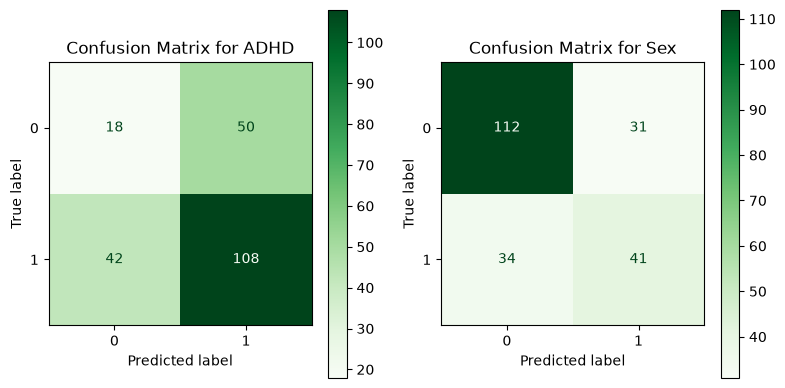

In [19]:
classification_report_adhd_sex(y_test, y_pred)

HIPERPARAMETERS:

In [20]:
model = MultiOutputClassifier(LogisticRegression(class_weight="balanced"))

In [21]:
param_dist = {
    'estimator__C': [0.001, 0.01, 0.1, 1, 10],
    'estimator__solver': ['liblinear', 'lbfgs', 'saga'],
    'estimator__penalty': ['l2', 'l1'],
    'estimator__max_iter': [500, 1000, 5000, 10000]
}

In [22]:
grid_search = GridSearchCV(model, param_dist, cv=5, scoring='f1_macro', n_jobs=-1, verbose=0)

grid_search.fit(X_train, y_train)

print("Best hyperparameters found:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
100 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\multioutput.py", line 543, in fit
    super().fit(X, Y, sample_weight=sample_weight, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python

Best hyperparameters found: {'estimator__C': 0.01, 'estimator__max_iter': 500, 'estimator__penalty': 'l2', 'estimator__solver': 'saga'}


Classification Report (Test Set):

--- ADHD ---
              precision    recall  f1-score   support

           0       0.35      0.32      0.34        68
           1       0.70      0.73      0.71       150

    accuracy                           0.60       218
   macro avg       0.53      0.53      0.53       218
weighted avg       0.59      0.60      0.60       218

Weighted F1 Score for ADHD: 0.6323

--- Sex ---
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       143
           1       0.57      0.57      0.57        75

    accuracy                           0.70       218
   macro avg       0.67      0.67      0.67       218
weighted avg       0.70      0.70      0.70       218

Weighted F1 Score for Sex: 0.7023

Average Weighted F1 Score (Final Score): 0.6673

Multi-label Confusion Matrix (Test Set):
[[[ 22  46]
  [ 41 109]]

 [[110  33]
  [ 32  43]]]


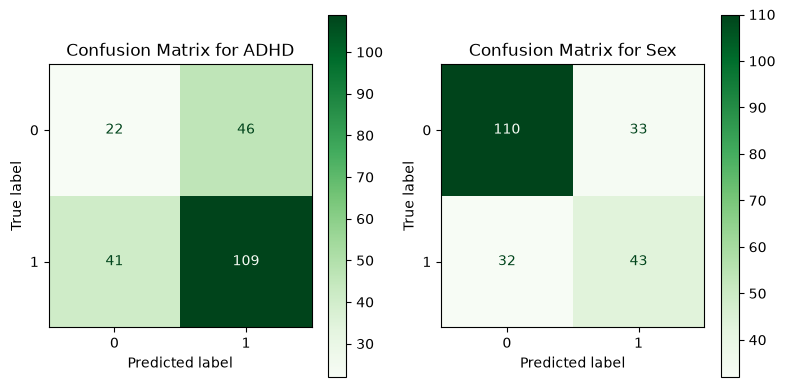

In [23]:
classification_report_adhd_sex(y_test, y_pred)

Two seperate models:

In [24]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'penalty': ['l1', 'l2'],
    'max_iter': [500, 1000, 5000, 10000]
}

# ADHD Model
grid_adhd = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_adhd.fit(X_train, y_train["ADHD_Outcome"])
print("Best ADHD model params:", grid_adhd.best_params_)

# Sex Model
grid_sex = GridSearchCV(
    LogisticRegression(class_weight='balanced'),
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)
grid_sex.fit(X_train, y_train["Sex_F"])
print("Best Sex model params:", grid_sex.best_params_)

adhd_preds_test = grid_adhd.predict(X_test)
sex_preds_test = grid_sex.predict(X_test)


Fitting 5 folds for each of 120 candidates, totalling 600 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
100 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\App

Best ADHD model params: {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'lbfgs'}
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Best Sex model params: {'C': 0.01, 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
100 fits failed out of a total of 600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
100 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Admin\App

In [25]:
print("\n--- ADHD Classification Report ---")
print(classification_report(y_test["ADHD_Outcome"], adhd_preds_test))
print("Confusion Matrix (ADHD):")
print(confusion_matrix(y_test["ADHD_Outcome"], adhd_preds_test))

print("\n--- Sex Classification Report ---")
print(classification_report(y_test["Sex_F"], sex_preds_test))
print("Confusion Matrix (Sex):")
print(confusion_matrix(y_test["Sex_F"], sex_preds_test))


--- ADHD Classification Report ---
              precision    recall  f1-score   support

           0       0.35      0.32      0.34        68
           1       0.70      0.73      0.71       150

    accuracy                           0.60       218
   macro avg       0.53      0.53      0.53       218
weighted avg       0.59      0.60      0.60       218

Confusion Matrix (ADHD):
[[ 22  46]
 [ 41 109]]

--- Sex Classification Report ---
              precision    recall  f1-score   support

           0       0.79      0.70      0.74       143
           1       0.53      0.65      0.59        75

    accuracy                           0.68       218
   macro avg       0.66      0.68      0.67       218
weighted avg       0.70      0.68      0.69       218

Confusion Matrix (Sex):
[[100  43]
 [ 26  49]]


# 3. XGBoost

### XGBOOST 1 model

In [26]:
multi_xgb = MultiOutputClassifier(xgb.XGBClassifier(
    objective = "binary:logistic",
    n_estimators = 500,
    learning_rate = 0.01,
    tree_method = "hist",
    n_jobs = -1,
    random_state = 42
))


In [27]:
multi_xgb.fit(X_train, y_train)

y_pred_xgb = multi_xgb.predict(X_test)

Classification Report (Test Set):

--- ADHD ---
              precision    recall  f1-score   support

           0       0.29      0.03      0.05        68
           1       0.69      0.97      0.80       150

    accuracy                           0.67       218
   macro avg       0.49      0.50      0.43       218
weighted avg       0.56      0.67      0.57       218

Weighted F1 Score for ADHD: 0.6364

--- Sex ---
              precision    recall  f1-score   support

           0       0.66      0.94      0.78       143
           1       0.38      0.07      0.11        75

    accuracy                           0.64       218
   macro avg       0.52      0.51      0.44       218
weighted avg       0.56      0.64      0.55       218

Weighted F1 Score for Sex: 0.5480

Average Weighted F1 Score (Final Score): 0.5922

Multi-label Confusion Matrix (Test Set):
[[[  2  66]
  [  5 145]]

 [[135   8]
  [ 70   5]]]


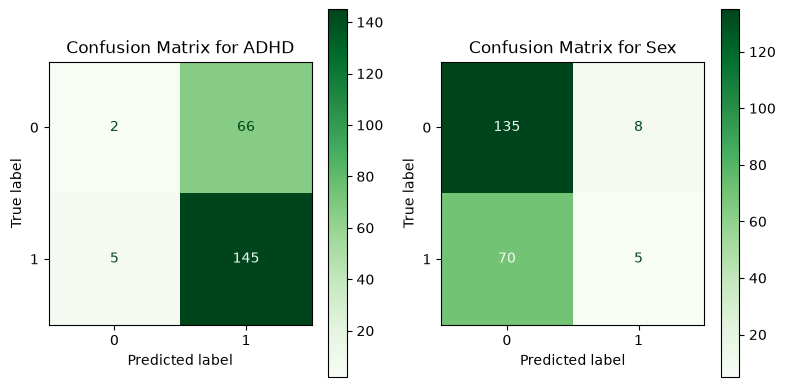

In [28]:
classification_report_adhd_sex(y_test, y_pred_xgb)

In [29]:
params_xgb_initial = {
    'objective': 'binary:logistic',
    'eval_metric': 'mlogloss',
    'booster': 'gbtree',
    'n_estimators': 200,
    'learning_rate': 0.01,
    'max_depth': 5,
    'min_child_weight': 2,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'gamma': 0.2,
    'reg_alpha': 0.1,
    'reg_lambda': 1.5,
    'scale_pos_weight': 2,
    'tree_method': 'hist',
    'n_jobs': -1,
    'random_state': 42
}

In [30]:
multi_clf_xgb_initial = MultiOutputClassifier(xgb.XGBClassifier(**params_xgb_initial))

In [31]:
multi_clf_xgb_initial.fit(X_train, y_train)

y_pred = multi_clf_xgb_initial.predict(X_test)

Classification Report (Test Set):

--- ADHD ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        68
           1       0.69      1.00      0.82       150

    accuracy                           0.69       218
   macro avg       0.34      0.50      0.41       218
weighted avg       0.47      0.69      0.56       218

Weighted F1 Score for ADHD: 0.6314

--- Sex ---
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       143
           1       0.56      0.29      0.39        75

    accuracy                           0.68       218
   macro avg       0.63      0.59      0.58       218
weighted avg       0.66      0.68      0.65       218

Weighted F1 Score for Sex: 0.6461

Average Weighted F1 Score (Final Score): 0.6388

Multi-label Confusion Matrix (Test Set):
[[[  0  68]
  [  0 150]]

 [[126  17]
  [ 53  22]]]


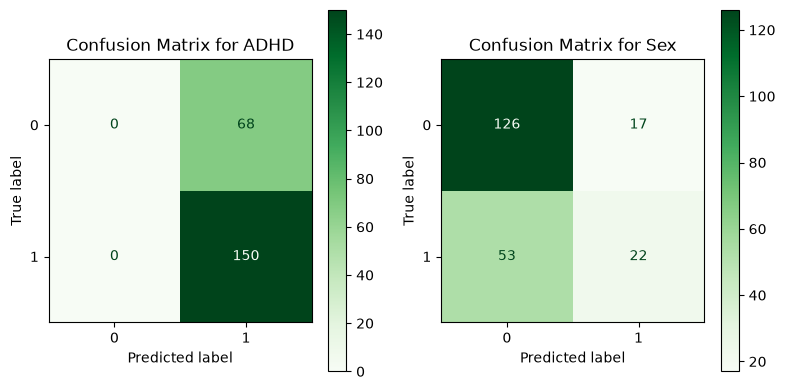

In [32]:
classification_report_adhd_sex(y_test, y_pred)

HYPERPARAMETR

In [33]:
param_dist = {
    'estimator__n_estimators': [200, 300, 400],
    'estimator__learning_rate': [0.001, 0.01, 0.05],
    'estimator__max_depth': [4, 5, 6],
    'estimator__min_child_weight': [1, 2],
    'estimator__subsample': [0.6, 0.8, 0.1],
    'estimator__colsample_bytree': [0.6, 0.8],
    'estimator__gamma': [0.1, 0.2],
    'estimator__reg_alpha': [0.01, 0.1, 1],
    'estimator__reg_lambda': [1, 1.5, 2],
    'estimator__scale_pos_weight': [1]
}

xgb_model = MultiOutputClassifier(xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='mlogloss',
    booster='gbtree',
    tree_method='hist',
    n_jobs=-1,
    random_state=42
))


In [34]:
grid_search = RandomizedSearchCV(
    xgb_model,
    param_dist,
    scoring='f1_weighted',
    n_iter=100,
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42,
    error_score='raise'
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_xgb_model = grid_search.best_estimator_
y_pred = best_xgb_model.predict(X_test)

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'estimator__subsample': 0.1, 'estimator__scale_pos_weight': 1, 'estimator__reg_lambda': 1, 'estimator__reg_alpha': 1, 'estimator__n_estimators': 400, 'estimator__min_child_weight': 2, 'estimator__max_depth': 6, 'estimator__learning_rate': 0.05, 'estimator__gamma': 0.1, 'estimator__colsample_bytree': 0.6}


Classification Report (Test Set):

--- ADHD ---
              precision    recall  f1-score   support

           0       0.33      0.10      0.16        68
           1       0.69      0.91      0.78       150

    accuracy                           0.66       218
   macro avg       0.51      0.50      0.47       218
weighted avg       0.58      0.66      0.59       218

Weighted F1 Score for ADHD: 0.6524

--- Sex ---
              precision    recall  f1-score   support

           0       0.68      0.90      0.77       143
           1       0.50      0.20      0.29        75

    accuracy                           0.66       218
   macro avg       0.59      0.55      0.53       218
weighted avg       0.62      0.66      0.61       218

Weighted F1 Score for Sex: 0.6056

Average Weighted F1 Score (Final Score): 0.6290

Multi-label Confusion Matrix (Test Set):
[[[  7  61]
  [ 14 136]]

 [[128  15]
  [ 60  15]]]


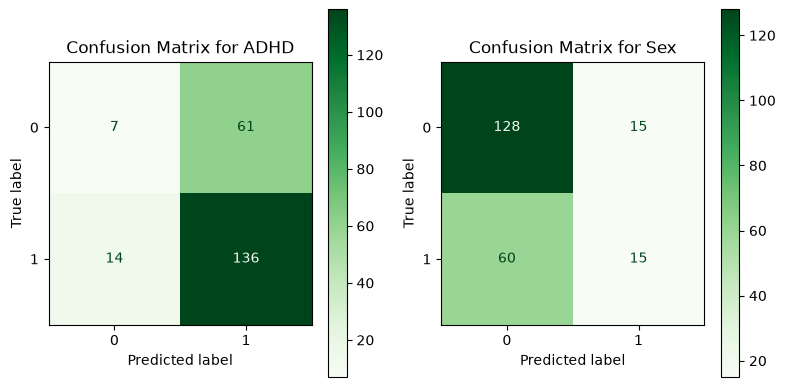

In [35]:
y_pred_prob = best_xgb_model.predict_proba(X_test)

classification_report_adhd_sex(y_test, y_pred)

### XGB - 2 seperate models - connected

In [ ]:
# Handle targets separately for better performance
model_adhd = XGBClassifier(tree_method='hist', enable_categorical=True)
model_sex = XGBClassifier(tree_method='hist', enable_categorical=True)

param_dist = {
    'learning_rate': stats.loguniform(1e-3, 0.3),
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200],
    'scale_pos_weight': [1, (224/101), (111/214)]
}

# Scoring for each target
search_adhd = RandomizedSearchCV(model_adhd, param_dist, n_iter=50,
                                scoring='f1_weighted', cv=5, n_jobs=-1)
search_sex = RandomizedSearchCV(model_sex, param_dist, n_iter=50,
                               scoring='f1_weighted', cv=5, n_jobs=-1)

search_adhd.fit(X_train, y_train_adhd)
search_sex.fit(X_train, y_train_sex)

adhd_pred = search_adhd.best_estimator_.predict(X_test)
sex_pred = search_sex.best_estimator_.predict(X_test)


In [ ]:
# Optimal scale_pos_weight
adhd_ratio = len(y_train_adhd[y_train_adhd==0])/len(y_train_adhd[y_train_adhd==1])
sex_ratio = len(y_train_sex[y_train_sex==0])/len(y_train_sex[y_train_sex==1])

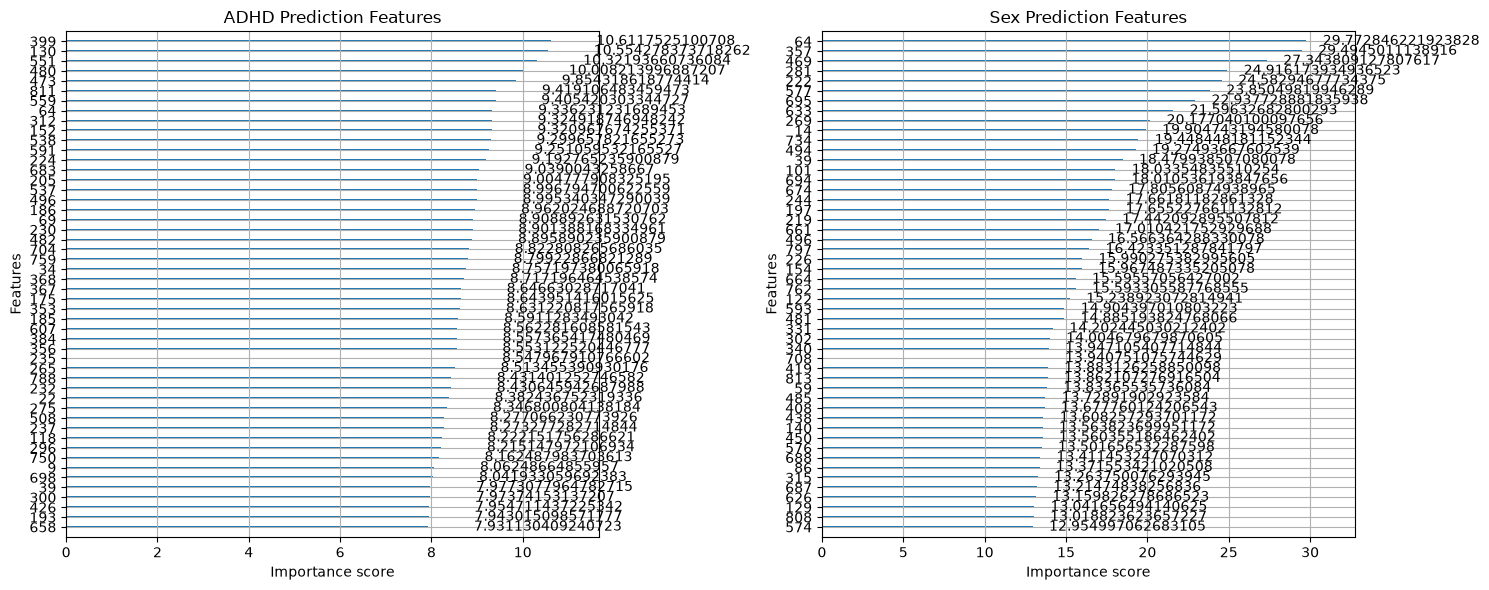

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ADHD importance
plot_importance(search_adhd.best_estimator_, ax=ax1, importance_type='gain', max_num_features=50)
ax1.set_title('ADHD Prediction Features')

# Gender importance
plot_importance(search_sex.best_estimator_, ax=ax2, importance_type='gain', max_num_features=50)
ax2.set_title('Sex Prediction Features')

plt.tight_layout()
plt.show()

In [ ]:
# feature importances
adhd_importances = search_adhd.best_estimator_.feature_importances_
sex_importances = search_sex.best_estimator_.feature_importances_

# sorted indices
adhd_indices = np.argsort(adhd_importances)[::-1]
sex_indices = np.argsort(sex_importances)[::-1]

# select top N features
top_n = 50
adhd_top_indices = adhd_indices[:top_n]
sex_top_indices = sex_indices[:top_n]

# Extract selected features - USING PROPER DATAFRAME INDEXING
X_adhd_selected = X_train.iloc[:, adhd_top_indices]
X_sex_selected = X_train.iloc[:, sex_top_indices]

# For testing data too
X_test_adhd = X_test.iloc[:, adhd_top_indices]
X_test_sex = X_test.iloc[:, sex_top_indices]

# Print most important features
print("Top 10 features for ADHD prediction:")
for i in range(10):
    print(f"Feature {adhd_top_indices[i]}: {adhd_importances[adhd_top_indices[i]]:.4f}")

print("\nTop 10 features for Sex prediction:")
for i in range(10):
    print(f"Feature {sex_top_indices[i]}: {sex_importances[sex_top_indices[i]]:.4f}")

Top 10 features for ADHD prediction:
Feature 399: 0.0028
Feature 130: 0.0028
Feature 551: 0.0027
Feature 480: 0.0027
Feature 473: 0.0026
Feature 811: 0.0025
Feature 559: 0.0025
Feature 64: 0.0025
Feature 312: 0.0025
Feature 152: 0.0025

Top 10 features for Sex prediction:
Feature 64: 0.0075
Feature 357: 0.0074
Feature 469: 0.0069
Feature 281: 0.0062
Feature 222: 0.0062
Feature 577: 0.0060
Feature 695: 0.0057
Feature 633: 0.0054
Feature 269: 0.0051
Feature 14: 0.0050


In [ ]:
# Train ADHD model with selected features
adhd_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=200,
    scale_pos_weight=224/101,  # Adjusted for class imbalance in ADHD
    tree_method='hist'
)
adhd_model.fit(X_adhd_selected, y_train_adhd)

# Train Sex model with selected features
sex_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_estimators=200,
    scale_pos_weight=214/111,  # Adjusted for class imbalance in Sex
    tree_method='hist'
)
sex_model.fit(X_sex_selected, y_train_sex)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
class CombinedPredictor:
    def __init__(self, adhd_model, sex_model, adhd_indices, sex_indices):
        self.adhd_model = adhd_model
        self.sex_model = sex_model
        self.adhd_indices = adhd_indices
        self.sex_indices = sex_indices

    def predict(self, X):
        """Make predictions for both ADHD and Sex"""
        # Extract appropriate features for each model
        X_adhd = X.iloc[:, self.adhd_indices] if hasattr(X, 'iloc') else X[:, self.adhd_indices]
        X_sex = X.iloc[:, self.sex_indices] if hasattr(X, 'iloc') else X[:, self.sex_indices]

        # Get predictions
        adhd_pred = self.adhd_model.predict(X_adhd)
        sex_pred = self.sex_model.predict(X_sex)

        # Combine predictions
        return np.column_stack((adhd_pred, sex_pred))

    def predict_proba(self, X):
        """Get probability predictions for both ADHD and Sex"""
        # Extract appropriate features for each model
        X_adhd = X.iloc[:, self.adhd_indices] if hasattr(X, 'iloc') else X[:, self.adhd_indices]
        X_sex = X.iloc[:, self.sex_indices] if hasattr(X, 'iloc') else X[:, self.sex_indices]

        # Get probability predictions
        adhd_proba = self.adhd_model.predict_proba(X_adhd)
        sex_proba = self.sex_model.predict_proba(X_sex)

        return [adhd_proba, sex_proba]


In [ ]:
# Combined model
combined_model = CombinedPredictor(
    adhd_model=adhd_model,
    sex_model=sex_model,
    adhd_indices=adhd_top_indices,
    sex_indices=sex_top_indices
)

y_pred_combined = combined_model.predict(X_test)

y_pred_adhd = y_pred_combined[:, 0]
y_pred_sex = y_pred_combined[:, 1]

print("\n--- ADHD Classification Report ---")
print(classification_report(y_test_adhd, y_pred_adhd))
adhd_f1 = f1_score(y_test_adhd, y_pred_adhd, average='weighted')
print(f"Weighted F1 Score for ADHD: {adhd_f1:.4f}")

print("\n--- Sex Classification Report ---")
print(classification_report(y_test_sex, y_pred_sex))
sex_f1 = f1_score(y_test_sex, y_pred_sex, average='weighted')
print(f"Weighted F1 Score for Sex: {sex_f1:.4f}")

# Overall score
print(f"\nAverage Weighted F1 Score: {(adhd_f1 + sex_f1)/2:.4f}")



--- ADHD Classification Report ---
              precision    recall  f1-score   support

           0       0.52      0.19      0.28        68
           1       0.72      0.92      0.80       150

    accuracy                           0.69       218
   macro avg       0.62      0.56      0.54       218
weighted avg       0.65      0.69      0.64       218

Weighted F1 Score for ADHD: 0.6409

--- Sex Classification Report ---
              precision    recall  f1-score   support

           0       0.68      0.76      0.72       143
           1       0.41      0.32      0.36        75

    accuracy                           0.61       218
   macro avg       0.54      0.54      0.54       218
weighted avg       0.59      0.61      0.59       218

Weighted F1 Score for Sex: 0.5924

Average Weighted F1 Score: 0.6166


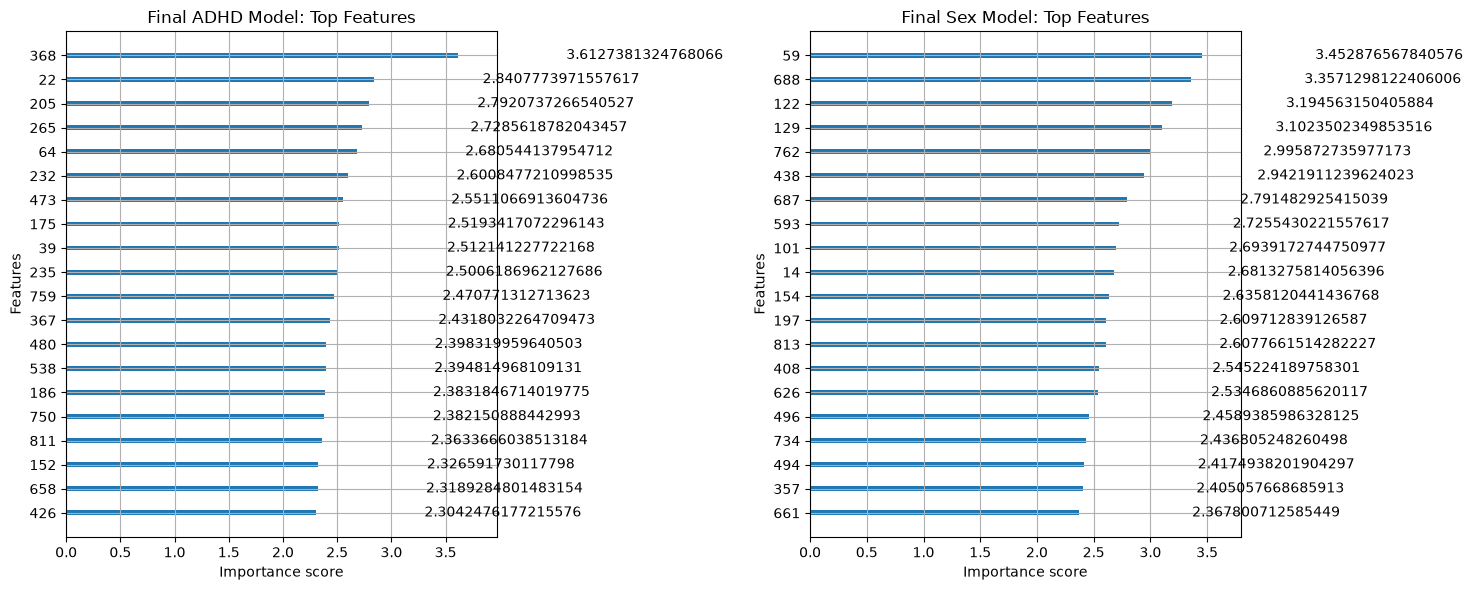

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

plot_importance(adhd_model, ax=ax1, importance_type='gain', max_num_features=20)
ax1.set_title('Final ADHD Model: Top Features')

plot_importance(sex_model, ax=ax2, importance_type='gain', max_num_features=20)
ax2.set_title('Final Sex Model: Top Features')

plt.tight_layout()
plt.savefig('final_feature_importance.png')
plt.show()


In [ ]:
y_train_adhd = y_train_adhd.to_numpy()
y_test_adhd = y_test_adhd.to_numpy()
y_train_sex = y_train_sex.to_numpy()
y_test_sex = y_test_sex.to_numpy()

# Calculate scale_pos_weight for ADHD
num_negative_adhd_train = np.sum(y_train_adhd == 0)
num_positive_adhd_train = np.sum(y_train_adhd == 1)
scale_pos_weight_adhd = num_negative_adhd_train / num_positive_adhd_train if num_positive_adhd_train > 0 else 1

# Calculate scale_pos_weight for Sex
num_negative_sex_train = np.sum(y_train_sex == 0)
num_positive_sex_train = np.sum(y_train_sex == 1)
scale_pos_weight_sex = num_negative_sex_train / num_positive_sex_train if num_positive_sex_train > 0 else 1

In [ ]:
# Model for ADHD
print("\n--- Training XGBoost Model for ADHD ---")
xgb_adhd = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight_adhd,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

xgb_adhd.fit(X_train, y_train_adhd)
y_pred_adhd = xgb_adhd.predict(X_test)

print("\nClassification Report (ADHD - Test Set):")
print(classification_report(y_test_adhd, y_pred_adhd, zero_division=0))
print("\nConfusion Matrix (ADHD - Test Set):")
print(confusion_matrix(y_test_adhd, y_pred_adhd))


--- Training XGBoost Model for ADHD ---

Classification Report (ADHD - Test Set):
              precision    recall  f1-score   support

           0       0.38      0.24      0.29        68
           1       0.70      0.83      0.76       150

    accuracy                           0.64       218
   macro avg       0.54      0.53      0.53       218
weighted avg       0.60      0.64      0.61       218


Confusion Matrix (ADHD - Test Set):
[[ 16  52]
 [ 26 124]]


In [ ]:
# Model for Gender = Female
print("\n--- Training XGBoost Model for Sex ---")
xgb_sex = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.01,
    max_depth=3,
    min_child_weight=2,
    subsample=0.6,
    colsample_bytree=0.6,
    gamma=0.2,
    reg_alpha=0.1,
    reg_lambda=1.5,
    scale_pos_weight=scale_pos_weight_sex,
    tree_method='hist',
    n_jobs=-1,
    random_state=42
)

xgb_sex.fit(X_train, y_train_sex)
y_pred_sex = xgb_sex.predict(X_test)

print("\nClassification Report (Sex - Test Set):")
print(classification_report(y_test_sex, y_pred_sex, zero_division=0))
print("\nConfusion Matrix (Sex - Test Set):")
print(confusion_matrix(y_test_sex, y_pred_sex))


--- Training XGBoost Model for Sex ---

Classification Report (Sex - Test Set):
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       143
           1       0.38      0.24      0.29        75

    accuracy                           0.60       218
   macro avg       0.52      0.52      0.51       218
weighted avg       0.57      0.60      0.57       218


Confusion Matrix (Sex - Test Set):
[[113  30]
 [ 57  18]]


In [ ]:
# Saving ADHD model
joblib.dump(xgb_adhd, 'adhd_model_pca_no_outliers.pkl')
print("\nADHD model saved as adhd_model_pca_no_outliers.pkl")

# Saving Sex model
joblib.dump(xgb_sex, 'sex_model_pca_no_outliers.pkl')
print("\nSex model saved as sex_model_pca_no_outliers.pkl")


ADHD model saved as adhd_model_pca_no_outliers.pkl

Sex model saved as sex_model_pca_no_outliers.pkl


In [ ]:
# Parallel Prediction Example
print("\n--- Parallel Prediction Example ---")

def predict_adhd_gender_parallel(brain_scan_data):
    """Predicts ADHD and Gender in parallel using loaded models."""
    loaded_adhd_model = joblib.load('adhd_model_pca_no_outliers.pkl')
    loaded_sex_model = joblib.load('sex_model_pca_no_outliers.pkl')

    adhd_prediction = loaded_adhd_model.predict(brain_scan_data)
    sex_prediction = loaded_sex_model.predict(brain_scan_data)
    return adhd_prediction, sex_prediction

# Example usage with the test data
parallel_adhd_preds, parallel_sex_preds = predict_adhd_gender_parallel(X_test)

print("\nFirst 10 Parallel Predictions (Test Data):")
for i in range(min(10, X_test.shape[0])):
    print(f"Patient {i+1}: Predicted ADHD = {parallel_adhd_preds[i]}, Predicted Sex = {parallel_sex_preds[i]}")


--- Parallel Prediction Example ---

First 10 Parallel Predictions (Test Data):
Patient 1: Predicted ADHD = 0, Predicted Sex = 1
Patient 2: Predicted ADHD = 0, Predicted Sex = 0
Patient 3: Predicted ADHD = 1, Predicted Sex = 0
Patient 4: Predicted ADHD = 1, Predicted Sex = 1
Patient 5: Predicted ADHD = 1, Predicted Sex = 0
Patient 6: Predicted ADHD = 1, Predicted Sex = 0
Patient 7: Predicted ADHD = 1, Predicted Sex = 0
Patient 8: Predicted ADHD = 0, Predicted Sex = 0
Patient 9: Predicted ADHD = 0, Predicted Sex = 1
Patient 10: Predicted ADHD = 1, Predicted Sex = 1



--- Evaluation ---

--- ADHD ---
              precision    recall  f1-score   support

           0       0.38      0.24      0.29        68
           1       0.70      0.83      0.76       150

    accuracy                           0.64       218
   macro avg       0.54      0.53      0.53       218
weighted avg       0.60      0.64      0.61       218


Confusion Matrix (ADHD):
[[ 16  52]
 [ 26 124]]

Accuracy (ADHD): 0.6422

--- Sex ---
              precision    recall  f1-score   support

           0       0.66      0.79      0.72       143
           1       0.38      0.24      0.29        75

    accuracy                           0.60       218
   macro avg       0.52      0.52      0.51       218
weighted avg       0.57      0.60      0.57       218


Confusion Matrix (Sex):
[[113  30]
 [ 57  18]]

Accuracy (Sex): 0.6009

Multi-label Confusion Matrix (Test Set):
[[[ 16  52]
  [ 26 124]]

 [[113  30]
  [ 57  18]]]


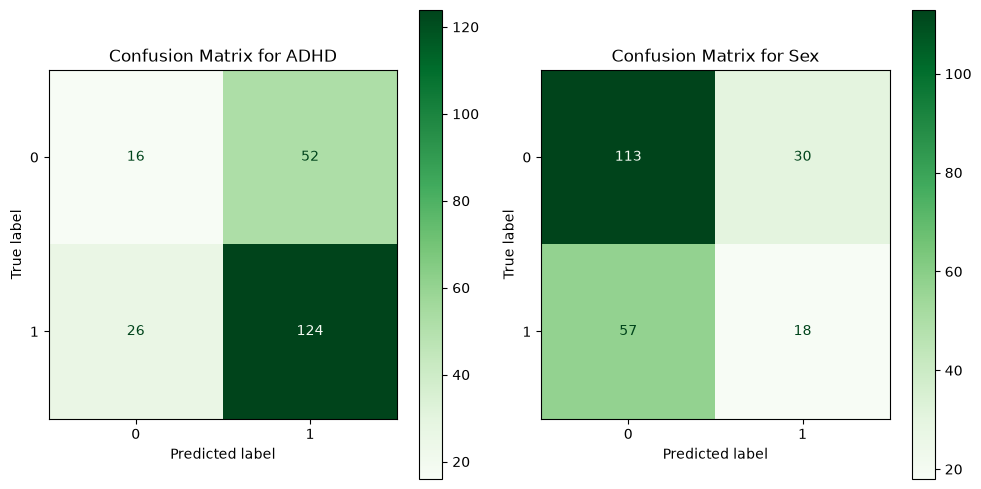


Models saved.


In [ ]:
# Combine predictions for overall metrics
y_pred_combined = np.column_stack((y_pred_adhd, y_pred_sex))
y_test_combined = np.column_stack((y_test_adhd, y_test_sex))

print("\n--- Evaluation ---")

labels = ['ADHD', 'Sex']

for i, label in enumerate(labels):
    print(f"\n--- {label} ---")
    print(
        classification_report(
            y_test_combined[:, i], y_pred_combined[:, i], zero_division=0
        )
    )  # Corrected indexing
    print(f"\nConfusion Matrix ({label}):")
    cm = confusion_matrix(y_test_combined[:, i], y_pred_combined[:, i])
    print(cm)

    # Calculate and print accuracy
    accuracy = accuracy_score(y_test_combined[:, i], y_pred_combined[:, i])
    print(f"\nAccuracy ({label}): {accuracy:.4f}")


# Multi-label Confusion Matrix (Test Set):
print("\nMulti-label Confusion Matrix (Test Set):")
print(multilabel_confusion_matrix(y_test_combined, y_pred_combined))

# Create subplots for smaller plot sizes
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Confusion Matrix for ADHD
cm_adhd = confusion_matrix(y_test_combined[:, 0], y_pred_combined[:, 0])
disp_adhd = ConfusionMatrixDisplay(confusion_matrix=cm_adhd)
disp_adhd.plot(cmap='Greens', ax=axes[0])
axes[0].set_title('Confusion Matrix for ADHD')

# Confusion Matrix for Sex
cm_sex = confusion_matrix(y_test_combined[:, 1], y_pred_combined[:, 1])
disp_sex = ConfusionMatrixDisplay(confusion_matrix=cm_sex)
disp_sex.plot(cmap='Greens', ax=axes[1])
axes[1].set_title('Confusion Matrix for Sex')

plt.tight_layout()
plt.show()

# Save the models
joblib.dump(xgb_adhd, 'adhd_model_pca_no_outliers.pkl')
joblib.dump(xgb_sex, 'sex_model_pca_no_outliers.pkl')
print("\nModels saved.")

In [ ]:
# ADHD MODEL

# Parameter distributions for RandomizedSearchCV (ADHD)
param_distributions_adhd = {
    'n_estimators': st.randint(50, 500),
    'learning_rate': st.loguniform(0.005, 0.3),
    'max_depth': st.randint(2, 10),
    'subsample': st.uniform(0.6, 0.4),
    'colsample_bytree': st.uniform(0.6, 0.4),
    'reg_alpha': st.uniform(0, 1.0),
    'reg_lambda': st.uniform(1, 5),
    'gamma': st.uniform(0, 0.5),
    'min_child_weight': st.randint(1, 10),
}

# XGBoost classifier for ADHD
xgb_adhd = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=scale_pos_weight_adhd,
    n_jobs=-1,
    random_state=42,
)

cv_adhd = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# RandomizedSearchCV for ADHD (optimizing F1)
n_iter_adhd = 500
random_search_adhd = RandomizedSearchCV(
    xgb_adhd,
    param_distributions=param_distributions_adhd,
    n_iter=n_iter_adhd,
    scoring='f1',
    cv=cv_adhd,
    refit=True,
    random_state=42,
    n_jobs=-1,
    error_score='raise',
)

random_search_adhd.fit(X_train, y_train_adhd)

print("Best parameters for ADHD (F1):", random_search_adhd.best_params_)
print("Best F1 score for ADHD:", random_search_adhd.best_score_)

Best parameters for ADHD (F1): {'colsample_bytree': np.float64(0.8217349897361379), 'gamma': np.float64(0.09975265746480422), 'learning_rate': np.float64(0.016659269958369142), 'max_depth': 9, 'min_child_weight': 2, 'n_estimators': 268, 'reg_alpha': np.float64(0.04005911905069448), 'reg_lambda': np.float64(2.4573045674689693), 'subsample': np.float64(0.6830163744822814)}
Best F1 score for ADHD: 0.8041497457819229


In [ ]:
# ADHD model with best parameters
best_xgb_adhd = xgb.XGBClassifier(
    **random_search_adhd.best_params_,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
)
best_xgb_adhd.fit(X_train, y_train_adhd)
y_pred_adhd = best_xgb_adhd.predict(X_test)

In [ ]:
# SEX MODEL

# Parameter distributions for RandomizedSearchCV (Sex)
param_distributions_sex = {
    'n_estimators': st.randint(50, 500),
    'learning_rate': st.loguniform(0.005, 0.3),
    'max_depth': st.randint(2, 10),
    'subsample': st.uniform(0.6, 0.4),
    'colsample_bytree': st.uniform(0.6, 0.4),
    'reg_alpha': st.uniform(0, 1.0),
    'reg_lambda': st.uniform(1, 5),
    'gamma': st.uniform(0, 0.5),
    'min_child_weight': st.randint(1, 10),
}

# XGBoost classifier for Sex_F
xgb_sex = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    scale_pos_weight=scale_pos_weight_sex,
    n_jobs=-1,
    random_state=42,
)

# Cross-validation strategy
cv_sex = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# RandomizedSearchCV for Sex (optimizing F1)
n_iter_sex = 500
random_search_sex = RandomizedSearchCV(
    xgb_sex,
    param_distributions=param_distributions_sex,
    n_iter=n_iter_sex,
    scoring='f1',
    cv=cv_sex,
    refit=True,
    random_state=42,
    n_jobs=-1,
    error_score='raise',
)

random_search_sex.fit(X_train, y_train_sex)

print("Best parameters for Sex (F1):", random_search_sex.best_params_)
print("Best F1 score for Sex:", random_search_sex.best_score_)

Best parameters for Sex (F1): {'colsample_bytree': np.float64(0.8783896824374792), 'gamma': np.float64(0.20447647220713494), 'learning_rate': np.float64(0.010165143555207987), 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 145, 'reg_alpha': np.float64(0.5492266647061205), 'reg_lambda': np.float64(4.572979613500312), 'subsample': np.float64(0.8640789506870925)}
Best F1 score for Sex: 0.4566169386196074


In [ ]:
# Sex_F model with best parameters
best_xgb_sex = xgb.XGBClassifier(
    **random_search_sex.best_params_,
    objective='binary:logistic',
    eval_metric='logloss',
    tree_method='hist',
    n_jobs=-1,
    random_state=42,
)
best_xgb_sex.fit(X_train, y_train_sex)
y_pred_sex = best_xgb_sex.predict(X_test)


--- Evaluation ---

--- ADHD ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        68
           1       0.69      1.00      0.82       150

    accuracy                           0.69       218
   macro avg       0.34      0.50      0.41       218
weighted avg       0.47      0.69      0.56       218


Confusion Matrix (ADHD):
[[  0  68]
 [  0 150]]

Accuracy (ADHD): 0.6881

--- Sex ---
              precision    recall  f1-score   support

           0       0.66      1.00      0.79       143
           1       0.00      0.00      0.00        75

    accuracy                           0.66       218
   macro avg       0.33      0.50      0.40       218
weighted avg       0.43      0.66      0.52       218


Confusion Matrix (Sex):
[[143   0]
 [ 75   0]]

Accuracy (Sex): 0.6560

Multi-label Confusion Matrix (Test Set):
[[[  0  68]
  [  0 150]]

 [[143   0]
  [ 75   0]]]


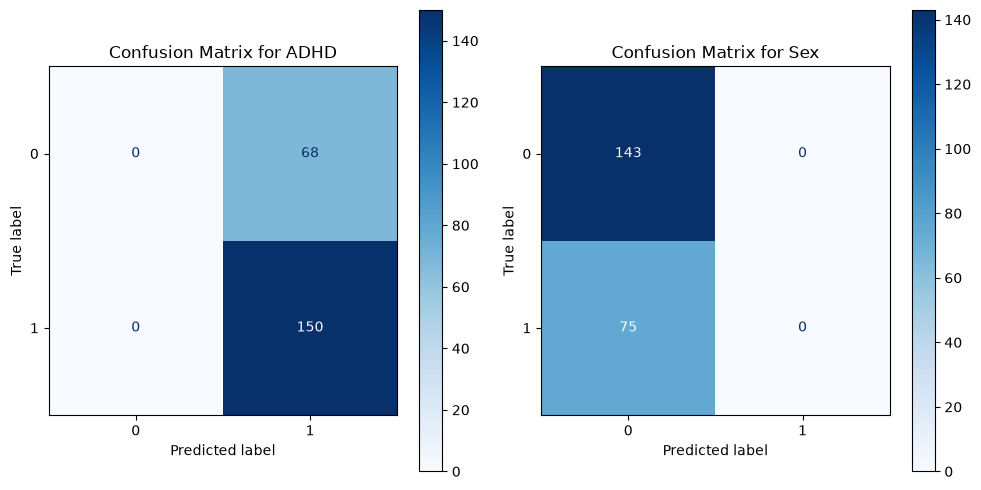

In [ ]:
# Combine predictions for overall metrics
y_pred_combined = np.column_stack((y_pred_adhd, y_pred_sex))
y_test_combined = np.column_stack((y_test_adhd, y_test_sex))


print("\n--- Evaluation ---")

labels = ['ADHD', 'Sex']

for i, label in enumerate(labels):
    print(f"\n--- {label} ---")
    print(
        classification_report(
            y_test_combined[:, i], y_pred_combined[:, i], zero_division=0
        )
    )
    print(f"\nConfusion Matrix ({label}):")
    cm = confusion_matrix(y_test_combined[:, i], y_pred_combined[:, i])
    print(cm)

    accuracy = accuracy_score(y_test_combined[:, i], y_pred_combined[:, i])
    print(f"\nAccuracy ({label}): {accuracy:.4f}")


# Multi-label Confusion Matrix (Test Set):
print("\nMulti-label Confusion Matrix (Test Set):")
print(multilabel_confusion_matrix(y_test_combined, y_pred_combined))


fig, axes = plt.subplots(1, 2, figsize=(10, 5))

cm_adhd = confusion_matrix(y_test_combined[:, 0], y_pred_combined[:, 0])
disp_adhd = ConfusionMatrixDisplay(confusion_matrix=cm_adhd)
disp_adhd.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix for ADHD')

cm_sex = confusion_matrix(y_test_combined[:, 1], y_pred_combined[:, 1])
disp_sex = ConfusionMatrixDisplay(confusion_matrix=cm_sex)
disp_sex.plot(cmap='Blues', ax=axes[1])
axes[1].set_title('Confusion Matrix for Sex')

plt.tight_layout()
plt.show()

In [ ]:
# Save the models
joblib.dump(best_xgb_adhd, 'adhd_model_pca_no_outliers_tuned.pkl')
joblib.dump(best_xgb_sex, 'sex_model_pca_no_outliers_tuned.pkl')
print("\nTuned models saved.")


Tuned models saved.


# 4. SVM


In [ ]:
print(y_train.columns)

Index(['ADHD_Outcome', 'Sex_F'], dtype='str')


In [ ]:
svm = SVC(kernel='rbf', class_weight='balanced', probability=True)

# Wrap in MultiOutputClassifier
multi_clf = MultiOutputClassifier(svm)

multi_clf.fit(X_train, y_train)
y_pred = multi_clf.predict(X_test)

y_pred = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])

def custom_weighted_f1(y_true, y_pred):
    if not isinstance(y_true, pd.DataFrame):
        y_true = pd.DataFrame(y_true, columns=['ADHD_Outcome', 'Sex_F'])
    if not isinstance(y_pred, pd.DataFrame):
        y_pred = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])

    mask_af = (y_true['ADHD_Outcome'] == 1) & (y_true['Sex_F'] == 1)
    weights = np.where(mask_af, 2.0, 1.0)

    f1_adhd_weighted = precision_recall_fscore_support(
        y_true['ADHD_Outcome'], y_pred['ADHD_Outcome'],
        sample_weight=weights, average='binary'
    )[2]

    f1_sex = precision_recall_fscore_support(
        y_true['Sex_F'], y_pred['Sex_F'],
        average='binary'
    )[2]

    return (f1_adhd_weighted + f1_sex) / 2

score = custom_weighted_f1(y_test, y_pred)
print(f"Custom Weighted F1 Score: {score:.4f}")


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Custom Weighted F1 Score: 0.6311


In [ ]:
y_pred_proba = multi_clf.predict_proba(X_test)

y_pred_proba = np.array(y_pred_proba)

print(y_pred_proba.shape)

adhd_pred_proba = y_pred_proba[0, :, 1]
sex_pred_proba = y_pred_proba[1, :, 1]

(2, 218, 2)


In [ ]:
y_pred_adjusted_adhd = (adhd_pred_proba >= 0.7).astype(int)
y_pred_adjusted_sex = (sex_pred_proba >= 0.3).astype(int)

print("Classification Report for ADHD_Outcome:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adjusted_adhd))
print("ADHD Confusion Matrix:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adjusted_adhd))

print("\nClassification Report for Sex_F:")
print(classification_report(y_test['Sex_F'], y_pred_adjusted_sex))
print("Gender Confusion Matrix:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adjusted_sex))

Classification Report for ADHD_Outcome:
              precision    recall  f1-score   support

           0       0.36      0.59      0.45        68
           1       0.74      0.53      0.62       150

    accuracy                           0.55       218
   macro avg       0.55      0.56      0.53       218
weighted avg       0.62      0.55      0.57       218

ADHD Confusion Matrix:
[[40 28]
 [70 80]]

Classification Report for Sex_F:
              precision    recall  f1-score   support

           0       0.81      0.62      0.70       143
           1       0.50      0.73      0.59        75

    accuracy                           0.66       218
   macro avg       0.66      0.67      0.65       218
weighted avg       0.71      0.66      0.66       218

Gender Confusion Matrix:
[[33 35]
 [75 75]]


In [ ]:
y_test_df = pd.DataFrame(y_test, columns=['ADHD_Outcome', 'Sex_F'])
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])

print("ADHD Diagnosis Report:")
print(classification_report(y_test_df['ADHD_Outcome'], y_pred_df['ADHD_Outcome'], digits=4))

print("ADHD Confusion Matrix:")
print(confusion_matrix(y_test_df['ADHD_Outcome'], y_pred_df['ADHD_Outcome']))

print("\nSex Classification Report:")
print(classification_report(y_test_df['Sex_F'], y_pred_df['Sex_F'], digits=4))

print("Sex Confusion Matrix:")
print(confusion_matrix(y_test_df['Sex_F'], y_pred_df['Sex_F']))

score = custom_weighted_f1(y_test_df, y_pred_df)
print(f"\nCustom Weighted F1 Score (Competition Metric): {score:.4f}")

ADHD Diagnosis Report:
              precision    recall  f1-score   support

           0     0.3864    0.2500    0.3036        68
           1     0.7069    0.8200    0.7593       150

    accuracy                         0.6422       218
   macro avg     0.5466    0.5350    0.5314       218
weighted avg     0.6069    0.6422    0.6171       218

ADHD Confusion Matrix:
[[ 17  51]
 [ 27 123]]

Sex Classification Report:
              precision    recall  f1-score   support

           0     0.7301    0.8322    0.7778       143
           1     0.5636    0.4133    0.4769        75

    accuracy                         0.6881       218
   macro avg     0.6468    0.6228    0.6274       218
weighted avg     0.6728    0.6881    0.6743       218

Sex Confusion Matrix:
[[119  24]
 [ 44  31]]

Custom Weighted F1 Score (Competition Metric): 0.6311


In [ ]:
svm_adhd = SVC(kernel='rbf', class_weight='balanced', probability=True)

weights = np.ones(len(y_train))
adhd_female_mask = (y_train['ADHD_Outcome'] == 1) & (y_train['Sex_F'] == 1)
weights[adhd_female_mask] = 2.0

svm_adhd.fit(X_train, y_train['ADHD_Outcome'], sample_weight=weights)

svm_sex = SVC(kernel='rbf', class_weight='balanced', probability=True)
svm_sex.fit(X_train, y_train['Sex_F'])

adhd_pred = svm_adhd.predict(X_test)
sex_pred = svm_sex.predict(X_test)

y_pred = pd.DataFrame({
    'ADHD_Outcome': adhd_pred,
    'Sex_F': sex_pred
})

def custom_weighted_f1(y_true, y_pred):
    if not isinstance(y_true, pd.DataFrame):
        y_true = pd.DataFrame(y_true, columns=['ADHD_Outcome', 'Sex_F'])
    if not isinstance(y_pred, pd.DataFrame):
        y_pred = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])

    mask_af = (y_true['ADHD_Outcome'] == 1) & (y_true['Sex_F'] == 1)
    weights = np.where(mask_af, 2.0, 1.0)

    f1_adhd_weighted = precision_recall_fscore_support(
        y_true['ADHD_Outcome'], y_pred['ADHD_Outcome'],
        sample_weight=weights, average='binary'
    )[2]

    f1_sex = precision_recall_fscore_support(
        y_true['Sex_F'], y_pred['Sex_F'],
        average='binary'
    )[2]

    return (f1_adhd_weighted + f1_sex) / 2

score = custom_weighted_f1(y_test, y_pred)
print(f"Custom Weighted F1 Score: {score:.4f}")

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Custom Weighted F1 Score: 0.6516


In [ ]:
y_test_df = pd.DataFrame(y_test, columns=['ADHD_Outcome', 'Sex_F'])
y_pred_df = pd.DataFrame(y_pred, columns=['ADHD_Outcome', 'Sex_F'])

print("ADHD Diagnosis Report:")
print(classification_report(y_test_df['ADHD_Outcome'], y_pred_df['ADHD_Outcome'], digits=4))

print("ADHD Confusion Matrix:")
print(confusion_matrix(y_test_df['ADHD_Outcome'], y_pred_df['ADHD_Outcome']))

print("\nSex Classification Report:")
print(classification_report(y_test_df['Sex_F'], y_pred_df['Sex_F'], digits=4))

print("Sex Confusion Matrix:")
print(confusion_matrix(y_test_df['Sex_F'], y_pred_df['Sex_F']))

score = custom_weighted_f1(y_test_df, y_pred_df)
print(f"\nCustom Weighted F1 Score (Competition Metric): {score:.4f}")

ADHD Diagnosis Report:
              precision    recall  f1-score   support

           0     0.4815    0.1912    0.2737        68
           1     0.7120    0.9067    0.7977       150

    accuracy                         0.6835       218
   macro avg     0.5968    0.5489    0.5357       218
weighted avg     0.6401    0.6835    0.6342       218

ADHD Confusion Matrix:
[[ 13  55]
 [ 14 136]]

Sex Classification Report:
              precision    recall  f1-score   support

           0     0.7301    0.8322    0.7778       143
           1     0.5636    0.4133    0.4769        75

    accuracy                         0.6881       218
   macro avg     0.6468    0.6228    0.6274       218
weighted avg     0.6728    0.6881    0.6743       218

Sex Confusion Matrix:
[[119  24]
 [ 44  31]]

Custom Weighted F1 Score (Competition Metric): 0.6516


In [ ]:
svm = SVC(probability=True)

multi_output_model = MultiOutputClassifier(svm)

param_grid = {
    'estimator__C': [0.1, 1, 10],
    'estimator__gamma': ['scale', 'auto'],
    'estimator__kernel': ['rbf', 'linear'],
    'estimator__class_weight': [None, 'balanced'],
}

grid_search = GridSearchCV(
    estimator=multi_output_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)

best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)

print("\nClassification Report for ADHD_Outcome:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_tuned[:, 0]))

print("ADHD Confusion Matrix:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_tuned[:, 0]))

print("\nClassification Report for Sex_F:")
print(classification_report(y_test['Sex_F'], y_pred_tuned[:, 1]))

print("Sex Confusion Matrix:")
print(confusion_matrix(y_test['Sex_F'], y_pred_tuned[:, 1]))

score = custom_weighted_f1(y_test, y_pred_df)
print(f"\nCustom Weighted F1 Score (Competition Metric): {score:.4f}")


Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Best parameters found:  {'estimator__C': 1, 'estimator__class_weight': 'balanced', 'estimator__gamma': 'scale', 'estimator__kernel': 'rbf'}

Classification Report for ADHD_Outcome:
              precision    recall  f1-score   support

           0       0.39      0.25      0.30        68
           1       0.71      0.82      0.76       150

    accuracy                           0.64       218
   macro avg       0.55      0.53      0.53       218
weighted avg       0.61      0.64      0.62       218

ADHD Confusion Matrix:
[[ 17  51]
 [ 27 123]]

Classification Report for Sex_F:
              precision    recall  f1-score   support

           0       0.73      0.83      0.78       143
           1       0.56      0.41      0.48        75

    accuracy                           0.69       218
   macro avg       0.65      0.62      0.63       218
weighted avg       0.67      0.69      0.67       218

Sex Confusion Matrix:
[[119  24]
 [ 44  31]]

Custom Weighted F1 Score (Competition M

# 5. Neural Network

1st Neural Network

In [ ]:
# Data
y_train_adhd = to_categorical(y_train['ADHD_Outcome'], num_classes=2)
y_train_sex = to_categorical(y_train['Sex_F'], num_classes=2)
y_test_adhd = to_categorical(y_test['ADHD_Outcome'], num_classes=2)
y_test_sex = to_categorical(y_test['Sex_F'], num_classes=2)

input_layer = Input(shape=(X_train.shape[1],))

x = Dense(128, activation='relu')(input_layer)
x = Dense(64, activation='relu')(x)
x = Dense(32, activation='relu')(x)

adhd_output = Dense(2, activation='softmax', name='adhd_output')(x)

sex_output = Dense(2, activation='softmax', name='sex_output')(x)

model = Model(inputs=input_layer, outputs=[adhd_output, sex_output])

model.compile(
    optimizer=Adam(),
    loss={'adhd_output': 'categorical_crossentropy', 'sex_output': 'categorical_crossentropy'},
    metrics=['accuracy', 'accuracy']
)

history = model.fit(
    X_train,
    {'adhd_output': y_train_adhd, 'sex_output': y_train_sex},
    epochs=50,
    batch_size=16,
    validation_data=(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex})
)

results = model.evaluate(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}, verbose=0)

for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value}")


y_pred = model.predict(X_test)

y_pred_adhd = y_pred[0]
y_pred = y_pred[1]

y_pred_adhd = y_pred_adhd.argmax(axis=1)
y_pred = y_pred.argmax(axis=1)


print("\nClassification Report for ADHD_Outcome:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nClassification Report for Sex_F:")
print(classification_report(y_test['Sex_F'], y_pred))

print("\nConfusion Matrix for ADHD_Outcome:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Sex_F:")
print(confusion_matrix(y_test['Sex_F'], y_pred))

def weighted_f1(y_true, y_pred, sex_true):
    f1 = f1_score(y_true, y_pred, average=None)
    mask_female_adhd = (y_true == 1) & (sex_true == 1)
    weight = np.where(mask_female_adhd, 2, 1)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', sample_weight=weight)
    return f1_weighted

final_weighted_f1 = weighted_f1(y_test['ADHD_Outcome'].values, y_pred_adhd, y_test['Sex_F'].values)
print(f"\nCustom Weighted F1 Score (female ADHD+ double): {final_weighted_f1:.4f}")

Epoch 1/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - adhd_output_accuracy: 0.6422 - adhd_output_loss: 0.6540 - loss: 1.3162 - sex_output_accuracy: 0.6365 - sex_output_loss: 0.6616 - val_adhd_output_accuracy: 0.6789 - val_adhd_output_loss: 0.6393 - val_loss: 1.2816 - val_sex_output_accuracy: 0.6193 - val_sex_output_loss: 0.6421
Epoch 2/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.7523 - adhd_output_loss: 0.4751 - loss: 0.7915 - sex_output_accuracy: 0.9025 - sex_output_loss: 0.3144 - val_adhd_output_accuracy: 0.6422 - val_adhd_output_loss: 0.6494 - val_loss: 1.3037 - val_sex_output_accuracy: 0.6835 - val_sex_output_loss: 0.6528
Epoch 3/50
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.8979 - adhd_output_loss: 0.2831 - loss: 0.3837 - sex_output_accuracy: 0.9862 - sex_output_loss: 0.0982 - val_adhd_output_accuracy: 0.6193 - val_adhd_output_loss: 0.7156 - val_loss: 1.4551 - val_sex_output_accuracy: 0.6927 - val_sex_output_loss: 0.7383
Epoch 4/50
55/55

In [ ]:
preds = model.predict(X_test)
adhd_probs = preds[0].flatten()
sex_probs = preds[1].flatten()

adhd_preds_class = (adhd_probs >= 0.5).astype(int)
sex_preds_class = (sex_probs >= 0.5).astype(int)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [ ]:
adhd_probs

array([4.96132642e-01, 5.03867388e-01, 2.78003892e-04, 9.99721944e-01,
       4.54417691e-02, 9.54558194e-01, 5.36932424e-02, 9.46306765e-01,
       8.35280865e-02, 9.16471958e-01, 1.98237813e-05, 9.99980211e-01,
       9.08753776e-04, 9.99091268e-01, 9.35068692e-06, 9.99990702e-01,
       9.99468982e-01, 5.31024765e-04, 9.93806869e-04, 9.99006212e-01,
       5.82067805e-05, 9.99941826e-01, 2.68759148e-04, 9.99731243e-01,
       1.24214971e-02, 9.87578452e-01, 9.99999166e-01, 8.82874815e-07,
       3.04627406e-07, 9.99999642e-01, 9.36055124e-01, 6.39448985e-02,
       2.39662568e-05, 9.99976039e-01, 5.04805565e-01, 4.95194435e-01,
       2.22970635e-01, 7.77029395e-01, 3.90384848e-05, 9.99961019e-01,
       7.16679733e-06, 9.99992847e-01, 6.01137799e-06, 9.99994040e-01,
       2.71212333e-03, 9.97287869e-01, 2.39401823e-04, 9.99760568e-01,
       5.64127229e-03, 9.94358718e-01, 1.87837720e-01, 8.12162280e-01,
       7.90863633e-02, 9.20913637e-01, 1.99200789e-04, 9.99800861e-01,
      

In [ ]:
true_adhd = y_test_adhd.flatten()
true_sex = y_test_sex.flatten()

# Custom weights: 2x if ADHD=1 and Sex=1
weights = 1 + ((true_adhd == 1) & (true_sex == 1)).astype(int)

# Weighted F1 for ADHD
f1_adhd = f1_score(true_adhd, adhd_preds_class, sample_weight=weights)

# F1 for sex
f1_sex = f1_score(true_sex, sex_preds_class)

# Final Kaggle-style average
final_score = (f1_adhd + f1_sex) / 2
print(f"Weighted F1 (ADHD): {f1_adhd:.4f}")
print(f"F1 (Sex): {f1_sex:.4f}")
print(f"Final Kaggle Score: {final_score:.4f}")


Weighted F1 (ADHD): 0.6548
F1 (Sex): 0.7156
Final Kaggle Score: 0.6852


Neural Network with dropouts and batch normalization

In [ ]:
y_train_adhd = to_categorical(y_train['ADHD_Outcome'], num_classes=2)
y_train_sex = to_categorical(y_train['Sex_F'], num_classes=2)
y_test_adhd = to_categorical(y_test['ADHD_Outcome'], num_classes=2)
y_test_sex = to_categorical(y_test['Sex_F'], num_classes=2)

input_layer = Input(shape=(X_train.shape[1],))

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0001))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu', kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(32, activation='relu')(x)
x = BatchNormalization()(x)

adhd_output = Dense(2, activation='softmax', name='adhd_output')(x)
sex_output = Dense(2, activation='softmax', name='sex_output')(x)

model = Model(inputs=input_layer, outputs=[adhd_output, sex_output])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss={'adhd_output': 'categorical_crossentropy', 'sex_output': 'categorical_crossentropy'},
    metrics=['accuracy', 'accuracy']
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1),
    checkpoint
]

history = model.fit(
    X_train,
    {'adhd_output': y_train_adhd, 'sex_output': y_train_sex},
    validation_data=(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

results = model.evaluate(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_adhd = np.argmax(y_pred_probs[0], axis=1)
y_pred = np.argmax(y_pred_probs[1], axis=1)

print("\nClassification Report for ADHD_Outcome:")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nClassification Report for Sex_F:")
print(classification_report(y_test['Sex_F'], y_pred))

print("\nConfusion Matrix for ADHD_Outcome:")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Sex_F:")
print(confusion_matrix(y_test['Sex_F'], y_pred))

def weighted_f1(y_true, y_pred, sex_true):
    f1 = f1_score(y_true, y_pred, average=None)
    mask_female_adhd = (y_true == 1) & (sex_true == 1)
    weight = np.where(mask_female_adhd, 2, 1)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', sample_weight=weight)
    return f1_weighted

final_weighted_f1 = weighted_f1(y_test['ADHD_Outcome'].values, y_pred_adhd, y_test['Sex_F'].values)
print(f"\nCustom Weighted F1 Score (female ADHD+ double): {final_weighted_f1:.4f}")


Epoch 1/100
39/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.4696 - adhd_output_loss: 1.0741 - loss: 1.9956 - sex_output_accuracy: 0.5288 - sex_output_loss: 0.8907 
Epoch 1: val_loss improved from None to 1.45616, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - adhd_output_accuracy: 0.4885 - adhd_output_loss: 1.0145 - loss: 1.9214 - sex_output_accuracy: 0.5298 - sex_output_loss: 0.8722 - val_adhd_output_accuracy: 0.5413 - val_adhd_output_loss: 0.7037 - val_loss: 1.4562 - val_sex_output_accuracy: 0.5046 - val_sex_output_loss: 0.7238 - learning_rate: 0.0010
Epoch 2/100
37/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.6807 - adhd_output_loss: 0.6018 - loss: 1.1506 - sex_output_accuracy: 0.7534 - sex_output_loss: 0.5174 
Epoch 2: val_loss did not improve from 1.45616
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - adhd_output_accuracy: 0.6892 - adhd_output_loss: 0.5944 - loss: 1.1517 - sex_output_accuracy: 0.7420 - sex_output_loss: 0.5243 - val_adhd_output_accuracy: 0.5688 - val_adhd_output_loss: 0.7252 - val_loss: 1.4750 - val_sex_output_accuracy: 0.5642 - val_sex_output_loss: 0.7202 - learning_rate: 0.0010
Epoch 3/100
47/55 ━━━━━━━━━━━━━━━━━━━━ 0s

Bigger network + bigger dropout

In [ ]:
y_train_adhd_labels = np.argmax(y_train_adhd, axis=1)
class_weights_adhd = class_weight.compute_class_weight('balanced', classes=np.unique(y_train_adhd_labels), y=y_train_adhd_labels)
class_weight_dict_adhd = {i: weight for i, weight in enumerate(class_weights_adhd)}

class_weights_tensor_adhd = tf.constant([class_weight_dict_adhd[0], class_weight_dict_adhd[1]], dtype=tf.float32)

def weighted_categorical_crossentropy_adhd(y_true, y_pred):
    y_true_argmax = K.argmax(y_true, axis=-1)
    weights = K.gather(class_weights_tensor_adhd, y_true_argmax)
    loss = K.categorical_crossentropy(y_true, y_pred) * weights
    return K.mean(loss)

input_layer = Input(shape=(X_train.shape[1],))

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0001))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)

adhd_output = Dense(2, activation='softmax', name='adhd_output')(x)
sex_output = Dense(2, activation='softmax', name='sex_output')(x)

model = Model(inputs=input_layer, outputs=[adhd_output, sex_output])

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.001,
    decay_steps=10000,
    decay_rate=0.9
)
optimizer = Adam(learning_rate=lr_schedule)

model.compile(
    optimizer=optimizer,
    loss={'adhd_output': weighted_categorical_crossentropy_adhd, 'sex_output': 'categorical_crossentropy'},
    loss_weights={'adhd_output': 1.0, 'sex_output': 1.0},
    metrics={'adhd_output': ['accuracy'], 'sex_output': ['accuracy']},
)

checkpoint = ModelCheckpoint(
    'best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    checkpoint
]

history = model.fit(
    X_train,
    {'adhd_output': y_train_adhd, 'sex_output': y_train_sex},
    validation_data=(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1,
)

results = model.evaluate(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_adhd = np.argmax(y_pred_probs[0], axis=1)
#custom_threshold = 0.4
#adhd_probs = y_pred_probs[0][:, 1]  # Class 1 = ADHD
#y_pred_adhd = (adhd_probs >= custom_threshold).astype(int)

y_pred = np.argmax(y_pred_probs[1], axis=1)
#custom_threshold_sex = 0.4
#sex_probs = y_pred_probs[1][:, 1]
#y_pred = (sex_probs >= custom_threshold_sex).astype(int)


print("\nClassification Report for ADHD_Outcome:")
print(classification_report(np.argmax(y_test_adhd, axis=1), y_pred_adhd))

print("\nClassification Report for Sex_F:")
print(classification_report(np.argmax(y_test_sex, axis=1), y_pred))

print("\nConfusion Matrix for ADHD_Outcome:")
print(confusion_matrix(np.argmax(y_test_adhd, axis=1), y_pred_adhd))

print("\nConfusion Matrix for Sex_F:")
print(confusion_matrix(np.argmax(y_test_sex, axis=1), y_pred))

def weighted_f1(y_true, y_pred, sex_true):
    f1 = f1_score(y_true, y_pred, average=None)
    mask_female_adhd = (y_true == 1) & (sex_true == 1)
    weight = np.where(mask_female_adhd, 2, 1)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', sample_weight=weight)
    return f1_weighted

final_weighted_f1 = weighted_f1(np.argmax(y_test_adhd, axis=1), y_pred_adhd, np.argmax(y_test_sex, axis=1))
print(f"\nCustom Weighted F1 Score (female ADHD+ double): {final_weighted_f1:.4f}")

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.5287 - adhd_output_loss: 0.9344 - loss: 1.8829 - sex_output_accuracy: 0.5046 - sex_output_loss: 0.8906
Epoch 1: val_loss improved from None to 1.46815, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - adhd_output_accuracy: 0.5287 - adhd_output_loss: 0.9344 - loss: 1.8829 - sex_output_accuracy: 0.5046 - sex_output_loss: 0.8906 - val_adhd_output_accuracy: 0.5275 - val_adhd_output_loss: 0.7616 - val_loss: 1.4681 - val_sex_output_accuracy: 0.6284 - val_sex_output_loss: 0.6480
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.7672 - adhd_output_loss: 0.4412 - loss: 0.9554 - sex_output_accuracy: 0.8028 - sex_output_loss: 0.4544
Epoch 2: val_loss did not improve from 1.46815
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - adhd_output_accuracy: 0.7672 - adhd_output_loss: 0.4412 - loss: 0.9554 - sex_output_accuracy: 0.8028 - sex_output_loss: 0.4544 - val_adhd_output_accuracy: 0.5780 - val_adhd_output_loss: 0.8244 - val_loss: 1.5362 - val_sex_output_accuracy: 0.6193 - val_sex_output_loss: 0.6539
Epoch 3/100
54/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.8727 - adhd_o

SMOTE:

In [ ]:
y_train_adhd = to_categorical(y_train['ADHD_Outcome'], num_classes=2)
y_train_sex = to_categorical(y_train['Sex_F'], num_classes=2)
y_test_adhd = to_categorical(y_test['ADHD_Outcome'], num_classes=2)
y_test_sex = to_categorical(y_test['Sex_F'], num_classes=2)

y_train_adhd_labels = np.argmax(y_train_adhd, axis=1)
y_train_sex_labels = np.argmax(y_train_sex, axis=1)


female_adhd_indices = np.where((y_train_sex_labels == 1) & (y_train_adhd_labels == 1))[0]
X_train_female_adhd = X_train.iloc[female_adhd_indices]
y_train_adhd_female_adhd = y_train_adhd_labels[female_adhd_indices]

# Apply SMOTE if there are instances to oversample
if len(np.unique(y_train_adhd_female_adhd)) > 1:
    smote = SMOTE(random_state=42)
    X_train_female_adhd_resampled, y_train_adhd_female_adhd_resampled = smote.fit_resample(
        X_train_female_adhd, y_train_adhd_female_adhd
    )

    # Identify indices for the rest of the training data
    remaining_indices = np.where(~((y_train_sex_labels == 1) & (y_train_adhd_labels == 1)))[0]
    X_train_remaining = X_train.iloc[remaining_indices]
    y_train_adhd_remaining = y_train_adhd[remaining_indices]
    y_train_sex_remaining = y_train_sex[remaining_indices]

    # Combine the resampled female ADHD data with the rest
    X_train_resampled = pd.concat([X_train_female_adhd_resampled, X_train_remaining], axis=0)
    y_train_adhd_resampled_labels = np.concatenate([y_train_adhd_female_adhd_resampled, np.argmax(y_train_adhd_remaining, axis=1)], axis=0)
    y_train_sex_resampled = pd.concat([y_train_sex[female_adhd_indices].iloc[[0]*len(y_train_adhd_female_adhd_resampled)], y_train_sex_remaining], axis=0) # Assuming Sex_F remains 1

    # Convert the resampled ADHD labels back to categorical
    y_train_adhd_resampled = to_categorical(y_train_adhd_resampled_labels, num_classes=2)

else:
    print("Warning: No or only one class found for females with ADHD. Skipping SMOTE for this group.")
    X_train_resampled = X_train.copy()
    y_train_adhd_resampled = y_train_adhd.copy()
    y_train_sex_resampled = y_train_sex.copy()

input_layer = Input(shape=(X_train_resampled.shape[1],))

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0001))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)


adhd_output = Dense(2, activation='softmax', name='adhd_output')(x)
sex_output = Dense(2, activation='softmax', name='sex_output')(x)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={'adhd_output': 'categorical_crossentropy', 'sex_output': 'categorical_crossentropy'},
    metrics=['accuracy', 'accuracy']
)

checkpoint = ModelCheckpoint(
    'best_model_smote_female_adhd.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1),
    checkpoint
]

history = model.fit(
    X_train_resampled,
    {'adhd_output': y_train_adhd_resampled, 'sex_output': y_train_sex_resampled},
    validation_data=(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

results = model.evaluate(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_adhd = np.argmax(y_pred_probs[0], axis=1)
y_pred = np.argmax(y_pred_probs[1], axis=1)

print("\nClassification Report for ADHD_Outcome (after SMOTE on female ADHD):")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nClassification Report for Sex_F (after SMOTE on female ADHD):")
print(classification_report(y_test['Sex_F'], y_pred))

print("\nConfusion Matrix for ADHD_Outcome (after SMOTE on female ADHD):")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Sex_F (after SMOTE on female ADHD):")
print(confusion_matrix(y_test['Sex_F'], y_pred))

def weighted_f1(y_true, y_pred, sex_true):
    f1 = f1_score(y_true, y_pred, average=None)
    mask_female_adhd = (y_true == 1) & (sex_true == 1)
    weight = np.where(mask_female_adhd, 2, 1)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', sample_weight=weight)
    return f1_weighted

final_weighted_f1 = weighted_f1(y_test['ADHD_Outcome'].values, y_pred_adhd, y_test['Sex_F'].values)
print(f"\nCustom Weighted F1 Score (female ADHD+ double) (after SMOTE on female ADHD): {final_weighted_f1:.4f}")

Epoch 1/100
32/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.7363 - adhd_output_loss: 0.4985 - loss: 1.0304 - sex_output_accuracy: 0.7871 - sex_output_loss: 0.4739 
Epoch 1: val_loss improved from None to 1.42465, saving model to best_model_smote_female_adhd.h5



Epoch 1: finished saving model to best_model_smote_female_adhd.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - adhd_output_accuracy: 0.7328 - adhd_output_loss: 0.5255 - loss: 1.0905 - sex_output_accuracy: 0.7649 - sex_output_loss: 0.5143 - val_adhd_output_accuracy: 0.6055 - val_adhd_output_loss: 0.7281 - val_loss: 1.4246 - val_sex_output_accuracy: 0.6193 - val_sex_output_loss: 0.6335 - learning_rate: 0.0010
Epoch 2/100
53/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.8903 - adhd_output_loss: 0.3025 - loss: 0.6506 - sex_output_accuracy: 0.8962 - sex_output_loss: 0.2883
Epoch 2: val_loss did not improve from 1.42465
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - adhd_output_accuracy: 0.8888 - adhd_output_loss: 0.3063 - loss: 0.6541 - sex_output_accuracy: 0.8968 - sex_output_loss: 0.2884 - val_adhd_output_accuracy: 0.6468 - val_adhd_output_loss: 0.7956 - val_loss: 1.5269 - val_sex_output_accuracy: 0.6743 - val_sex_output_loss: 0.6657 - learning_rate: 0.0010
Epoch 3/100
49/55 ━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step

Classification Report for ADHD_Outcome (after SMOTE on female ADHD):
              precision    recall  f1-score   support

           0       0.28      0.16      0.20        68
           1       0.68      0.81      0.74       150

    accuracy                           0.61       218
   macro avg       0.48      0.48      0.47       218
weighted avg       0.55      0.61      0.57       218


Classification Report for Sex_F (after SMOTE on female ADHD):
              precision    recall  f1-score   support

           0       0.69      0.78      0.73       143
           1       0.43      0.32      0.37        75

    accuracy                           0.62       218
   macro avg       0.56      0.55      0.55       218
weighted avg       0.60      0.62      0.60       218


Confusion Matrix for ADHD_Outcome (after SMOTE on female ADHD):
[[ 11  57]
 [ 29 121]]

Confusion Matrix for Sex_F (after SMOTE on female ADHD):
[[111  32]
 [ 51  24]]

Custom

In [ ]:
y_train_adhd = to_categorical(y_train['ADHD_Outcome'], num_classes=2)
y_train_sex = to_categorical(y_train['Sex_F'], num_classes=2)
y_test_adhd = to_categorical(y_test['ADHD_Outcome'], num_classes=2)
y_test_sex = to_categorical(y_test['Sex_F'], num_classes=2)

y_train_adhd_labels = np.argmax(y_train_adhd, axis=1)
y_train_sex_labels = np.argmax(y_train_sex, axis=1)

female_adhd_indices = np.where((y_train_sex_labels == 1) & (y_train_adhd_labels == 1))[0]
X_train_female_adhd = X_train.iloc[female_adhd_indices]
y_train_adhd_female_adhd = y_train_adhd_labels[female_adhd_indices]

if len(np.unique(y_train_adhd_female_adhd)) > 1:
    smote = SMOTE(random_state=42)
    X_train_female_adhd_resampled, y_train_adhd_female_adhd_resampled = smote.fit_resample(
        X_train_female_adhd, y_train_adhd_female_adhd
    )

    remaining_indices = np.where(~((y_train_sex_labels == 1) & (y_train_adhd_labels == 1)))[0]
    X_train_remaining = X_train.iloc[remaining_indices]
    y_train_adhd_remaining = y_train_adhd[remaining_indices]
    y_train_sex_remaining = y_train_sex[remaining_indices]

    X_train_resampled = pd.concat([X_train_female_adhd_resampled, X_train_remaining], axis=0)
    y_train_adhd_resampled_labels = np.concatenate([y_train_adhd_female_adhd_resampled, np.argmax(y_train_adhd_remaining, axis=1)], axis=0)
    y_train_sex_resampled = pd.concat([y_train_sex[female_adhd_indices].iloc[[0]*len(y_train_adhd_female_adhd_resampled)], y_train_sex_remaining], axis=0) # Assuming Sex_F remains 1

    y_train_adhd_resampled = to_categorical(y_train_adhd_resampled_labels, num_classes=2)

else:
    print("Warning: No or only one class found for females with ADHD. Skipping SMOTE for this group.")
    X_train_resampled = X_train.copy()
    y_train_adhd_resampled = y_train_adhd.copy()
    y_train_sex_resampled = y_train_sex.copy()

input_layer = Input(shape=(X_train_resampled.shape[1],))

x = Dense(256, activation='elu', kernel_regularizer=l2(0.0001))(input_layer)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(128, activation='elu', kernel_regularizer=l2(0.0001))(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Dense(64, activation='elu')(x)
x = BatchNormalization()(x)

adhd_output = Dense(2, activation='softmax', name='adhd_output')(x)
sex_output = Dense(2, activation='softmax', name='sex_output')(x)

model = Model(inputs=input_layer, outputs=[adhd_output, sex_output])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={'adhd_output': 'categorical_crossentropy', 'sex_output': 'categorical_crossentropy'},
    metrics=['accuracy', 'accuracy']
)

checkpoint = ModelCheckpoint(
    'best_model_smote_female_adhd.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.2, verbose=1),
    checkpoint
]

history = model.fit(
    X_train_resampled,
    {'adhd_output': y_train_adhd_resampled, 'sex_output': y_train_sex_resampled},
    validation_data=(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    verbose=1
)

results = model.evaluate(X_test, {'adhd_output': y_test_adhd, 'sex_output': y_test_sex}, verbose=0)
for name, val in zip(model.metrics_names, results):
    print(f"{name}: {val:.4f}")

y_pred_probs = model.predict(X_test)
y_pred_adhd = np.argmax(y_pred_probs[0], axis=1)
y_pred = np.argmax(y_pred_probs[1], axis=1)

print("\nClassification Report for ADHD_Outcome (after SMOTE on female ADHD):")
print(classification_report(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nClassification Report for Sex_F (after SMOTE on female ADHD):")
print(classification_report(y_test['Sex_F'], y_pred))

print("\nConfusion Matrix for ADHD_Outcome (after SMOTE on female ADHD):")
print(confusion_matrix(y_test['ADHD_Outcome'], y_pred_adhd))

print("\nConfusion Matrix for Sex_F (after SMOTE on female ADHD):")
print(confusion_matrix(y_test['Sex_F'], y_pred))

def weighted_f1(y_true, y_pred, sex_true):
    f1 = f1_score(y_true, y_pred, average=None)
    mask_female_adhd = (y_true == 1) & (sex_true == 1)
    weight = np.where(mask_female_adhd, 2, 1)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', sample_weight=weight)
    return f1_weighted

final_weighted_f1 = weighted_f1(y_test['ADHD_Outcome'].values, y_pred_adhd, y_test['Sex_F'].values)
print(f"\nCustom Weighted F1 Score (female ADHD+ double) (after SMOTE on female ADHD): {final_weighted_f1:.4f}")

Epoch 1/100
30/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.5375 - adhd_output_loss: 1.0506 - loss: 2.0421 - sex_output_accuracy: 0.5083 - sex_output_loss: 0.9350 
Epoch 1: val_loss improved from None to 1.50061, saving model to best_model_smote_female_adhd.h5



Epoch 1: finished saving model to best_model_smote_female_adhd.h5
55/55 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - adhd_output_accuracy: 0.5528 - adhd_output_loss: 0.9794 - loss: 1.9326 - sex_output_accuracy: 0.5229 - sex_output_loss: 0.8937 - val_adhd_output_accuracy: 0.5917 - val_adhd_output_loss: 0.7161 - val_loss: 1.5006 - val_sex_output_accuracy: 0.6101 - val_sex_output_loss: 0.7261 - learning_rate: 0.0010
Epoch 2/100
34/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - adhd_output_accuracy: 0.8033 - adhd_output_loss: 0.4382 - loss: 0.8747 - sex_output_accuracy: 0.8419 - sex_output_loss: 0.3787 
Epoch 2: val_loss did not improve from 1.50061
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - adhd_output_accuracy: 0.8200 - adhd_output_loss: 0.4067 - loss: 0.8289 - sex_output_accuracy: 0.8463 - sex_output_loss: 0.3638 - val_adhd_output_accuracy: 0.5917 - val_adhd_output_loss: 0.7846 - val_loss: 1.5683 - val_sex_output_accuracy: 0.6376 - val_sex_output_loss: 0.7275 - learning_rate: 0.0010
Epoch 3/100
45/55 ━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

Classification Report for ADHD_Outcome (after SMOTE on female ADHD):
              precision    recall  f1-score   support

           0       0.35      0.37      0.36        68
           1       0.71      0.69      0.70       150

    accuracy                           0.59       218
   macro avg       0.53      0.53      0.53       218
weighted avg       0.60      0.59      0.59       218


Classification Report for Sex_F (after SMOTE on female ADHD):
              precision    recall  f1-score   support

           0       0.75      0.60      0.67       143
           1       0.45      0.63      0.53        75

    accuracy                           0.61       218
   macro avg       0.60      0.61      0.60       218
weighted avg       0.65      0.61      0.62       218


Confusion Matrix for ADHD_Outcome (after SMOTE on female ADHD):
[[ 25  43]
 [ 46 104]]

Confusion Matrix for Sex_F (after SMOTE on female ADHD):
[[86 57]
 [28 47]]

Custom We

In [ ]:
import os
import joblib
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# إنشاء مجلد الحفظ
os.makedirs("models", exist_ok=True)

# ===========================
# Define Models
# ===========================

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        kernel="rbf",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(128,64),
        max_iter=500,
        random_state=42
    )
}

results = []

best_model = None
best_name = ""
best_auc = -1
best_f1 = -1

# ===========================
# Train & Evaluate
# ===========================

for name, model in models.items():

    print(f"\nTraining {name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    pre = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        "Model":name,
        "Accuracy":acc,
        "Precision":pre,
        "Recall":rec,
        "F1":f1,
        "ROC_AUC":auc
    })

    if auc > best_auc or (auc == best_auc and f1 > best_f1):

        best_auc = auc
        best_f1 = f1
        best_model = model
        best_name = name

# ===========================
# Results
# ===========================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by=["ROC_AUC","F1"],
    ascending=False
)

print("\n==============================")
print(results_df)
print("==============================")

# ===========================
# Save Best Model
# ===========================

joblib.dump(best_model,"models/best_tabular_model.pkl")

print("\n🏆 Best Model :",best_name)
print("ROC AUC :",round(best_auc,4))
print("F1 :",round(best_f1,4))
print("Saved to models/best_tabular_model.pkl")

In [ ]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(scaler, "models/scaler.pkl")

print("✅ Scaler saved.")

In [ ]:
import joblib

model = joblib.load("best_model.joblib")

In [ ]:
import joblib

best_model = grid_search.best_estimator_


joblib.dump(best_model, "best_model.joblib")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import joblib

joblib.dump(model, "best_model.joblib")

['best_model.joblib']

In [ ]:
import joblib

model = joblib.load("best_model.joblib")

In [ ]:
import os

print(os.getcwd())

c:\Users\Admin\Downloads


In [ ]:
import joblib

joblib.dump(model, r"C:\Users\Admin\Downloads\model_adhd\adhd_pipeline.joblib")

['C:\\Users\\Admin\\Downloads\\model_adhd\\adhd_pipeline.joblib']